## 📋 Daftar Isi
1. [Setup & Import Libraries](#1-setup)
2. [Data Loading & Eksplorasi](#2-data-loading)
3. [Data Preprocessing](#3-preprocessing)
   - 3.1 Deteksi Outlier (IQR)
   - 3.2 Standarisasi Fitur (StandardScaler)
4. [Penentuan Jumlah Cluster Optimal](#4-optimal-k)
   - 4.1 Elbow Method
   - 4.2 Silhouette Analysis
5. [K-Means Clustering](#5-kmeans)
6. [Ward's Hierarchical Clustering](#6-hierarchical)
   - 6.1 Dendrogram
   - 6.2 Penerapan & Validasi
7. [Visualisasi PCA 2D](#7-pca)
8. [Profil Cluster & Pelabelan Risiko](#8-profiling)
9. [Rekomendasi Strategis](#9-rekomendasi)

## 1. Setup & Import Libraries <a id='1-setup'></a>

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import glob
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score

# ── Hierarchical Clustering ───────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

# ── Global Aesthetics ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
PALETTE     = sns.color_palette('husl', 6)
RANDOM_STATE = 42

print("✅ Semua library berhasil dimuat.")
print(f"   Pandas     : {pd.__version__}")
print(f"   NumPy      : {np.__version__}")
print(f"   Scikit-learn sudah siap.")

✅ Semua library berhasil dimuat.
   Pandas     : 2.3.3
   NumPy      : 2.4.1
   Scikit-learn sudah siap.


## 2. Data Loading & Eksplorasi <a id='2-data-loading'></a>
Data diambil dari **5 file Excel** (2020–2024) yang masing-masing berisi 38 Kabupaten/Kota Jawa Timur.
Baris dengan kata kunci **"Jawa Timur"** (ringkasan provinsi) **diabaikan** sesuai instruksi.
Nilai agregasi multi-tahun menggunakan **median** untuk ketahanan terhadap anomali data.

In [2]:
# ── Konfigurasi ───────────────────────────────────────────────────────────────
DATA_DIR  = "tingkat kriminalitas"
FILES     = sorted(glob.glob(os.path.join(DATA_DIR, "*.xlsx")))

COL_NAMES    = ['Kabupaten_Kota', 'Jumlah_Kejahatan', 'Risiko_100k',
                'Persen_Penyelesaian', 'Selang_Waktu']
FEATURE_COLS = COL_NAMES[1:]

FEATURE_LABELS = {
    'Jumlah_Kejahatan'   : 'Jml Kejahatan\nDilaporkan',
    'Risiko_100k'        : 'Risiko per\n100k Penduduk',
    'Persen_Penyelesaian': '% Penyelesaian\nKasus',
    'Selang_Waktu'       : 'Selang Waktu\nKejadian (jam)',
}

print(f"📂 Ditemukan {len(FILES)} file:")
for f in FILES:
    print(f"   • {os.path.basename(f)}")

📂 Ditemukan 5 file:
   • tingkat kriminalitas 2020.xlsx
   • tingkat kriminalitas 2021.xlsx
   • tingkat kriminalitas 2022.xlsx
   • tingkat kriminalitas 2023.xlsx
   • tingkat kriminalitas 2024.xlsx


In [3]:
def load_year_data(filepath: str) -> pd.DataFrame:
    """
    Memuat satu file Excel, menghapus baris 'Jawa Timur', baris metadata/catatan,
    dan mengkonversi semua kolom numerik.
    """
    year = int(os.path.basename(filepath).split()[-1].replace('.xlsx', ''))
    df   = pd.read_excel(filepath, header=0)
    df.columns = COL_NAMES

    # ① Filter baris 'Jawa Timur' (case-insensitive)
    mask_jatim = df['Kabupaten_Kota'].astype(str).str.lower().str.contains('jawa timur', na=True)
    df = df[~mask_jatim].copy()

    # ② Konversi ke numerik; nilai tidak valid → NaN
    for col in FEATURE_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # ③ Hapus baris metadata (catatan, sumber, HTML-tag, dll.)
    df = df[df['Kabupaten_Kota'].notna()].copy()
    df = df[~df['Kabupaten_Kota'].astype(str).str.match(
        r'^[<\d]|catatan|sumber|source|note', flags=0, na=True
    )].copy()

    # ④ Hanya simpan baris dengan ≥ 3 kolom numerik valid
    valid_mask = df[FEATURE_COLS].notna().sum(axis=1) >= 3
    df = df[valid_mask].copy()

    df['Tahun'] = year
    return df


# ── Load & gabungkan ──────────────────────────────────────────────────────────
dfs    = [load_year_data(f) for f in FILES]
df_raw = pd.concat(dfs, ignore_index=True)
df_raw[FEATURE_COLS] = df_raw[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')

print(f"✅ Total rekaman: {len(df_raw)}")
print(f"   Tahun     : {sorted(df_raw['Tahun'].unique())}")
print(f"   Kabupaten : {df_raw['Kabupaten_Kota'].nunique()} daerah unik")
df_raw.head(10)

✅ Total rekaman: 190
   Tahun     : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
   Kabupaten : 38 daerah unik


,Kabupaten_Kota,Jumlah_Kejahatan,Risiko_100k,Persen_Penyelesaian,Selang_Waktu,Tahun
0,Pacitan,72.0,13.0,90.28,100.0,2020
1,Ponorogo,402.0,47.0,87.81,1307.0,2020
2,Trenggalek,595.0,88.0,90.59,883.0,2020
3,Tulungagung,538.0,54.0,100.74,977.0,2020
4,Blitar,304.0,27.0,27.30,289.0,2020
5,Kediri,862.0,57.0,38.75,610.0,2020
6,Malang,1850.0,75.0,69.35,284.0,2020
7,Lumajang,356.0,35.0,12.64,36.0,2020
8,Jember,1061.0,45.0,62.49,495.0,2020
9,Banyuwangi,893.0,57.0,47.70,589.0,2020


In [4]:
# ── Agregasi multi-tahun: median per Kabupaten/Kota ──────────────────────────
# Median lebih robust terhadap anomali data tahun tertentu (mis. 2024)
df_profile = (df_raw
              .groupby('Kabupaten_Kota', sort=True)[FEATURE_COLS]
              .median()
              .reset_index())

print(f"✅ Dataset profil final: {df_profile.shape[0]} Kabupaten/Kota × {len(FEATURE_COLS)} fitur")
print("\n📊 Statistik Deskriptif:")
df_profile[FEATURE_COLS].describe().round(2)

✅ Dataset profil final: 38 Kabupaten/Kota × 4 fitur

📊 Statistik Deskriptif:


,Jumlah_Kejahatan,Risiko_100k,Persen_Penyelesaian,Selang_Waktu
count,38.00,38.00,38.00,38.00
mean,1122.82,54.32,86.18,657.27
std,441.28,47.67,13.02,239.75
min,300.00,6.00,46.42,231.60
25%,764.25,28.50,81.60,447.00
50%,1057.50,42.50,86.24,682.00
75%,1501.75,56.25,95.29,835.75
max,2009.00,222.00,109.16,1215.00


### 2.1 Histogram Distribusi Variabel
Visualisasi distribusi setiap variabel numerik dengan anotasi **mean**, **median**, serta ringkasan statistik dasar (min, Q1, median, Q3, max).

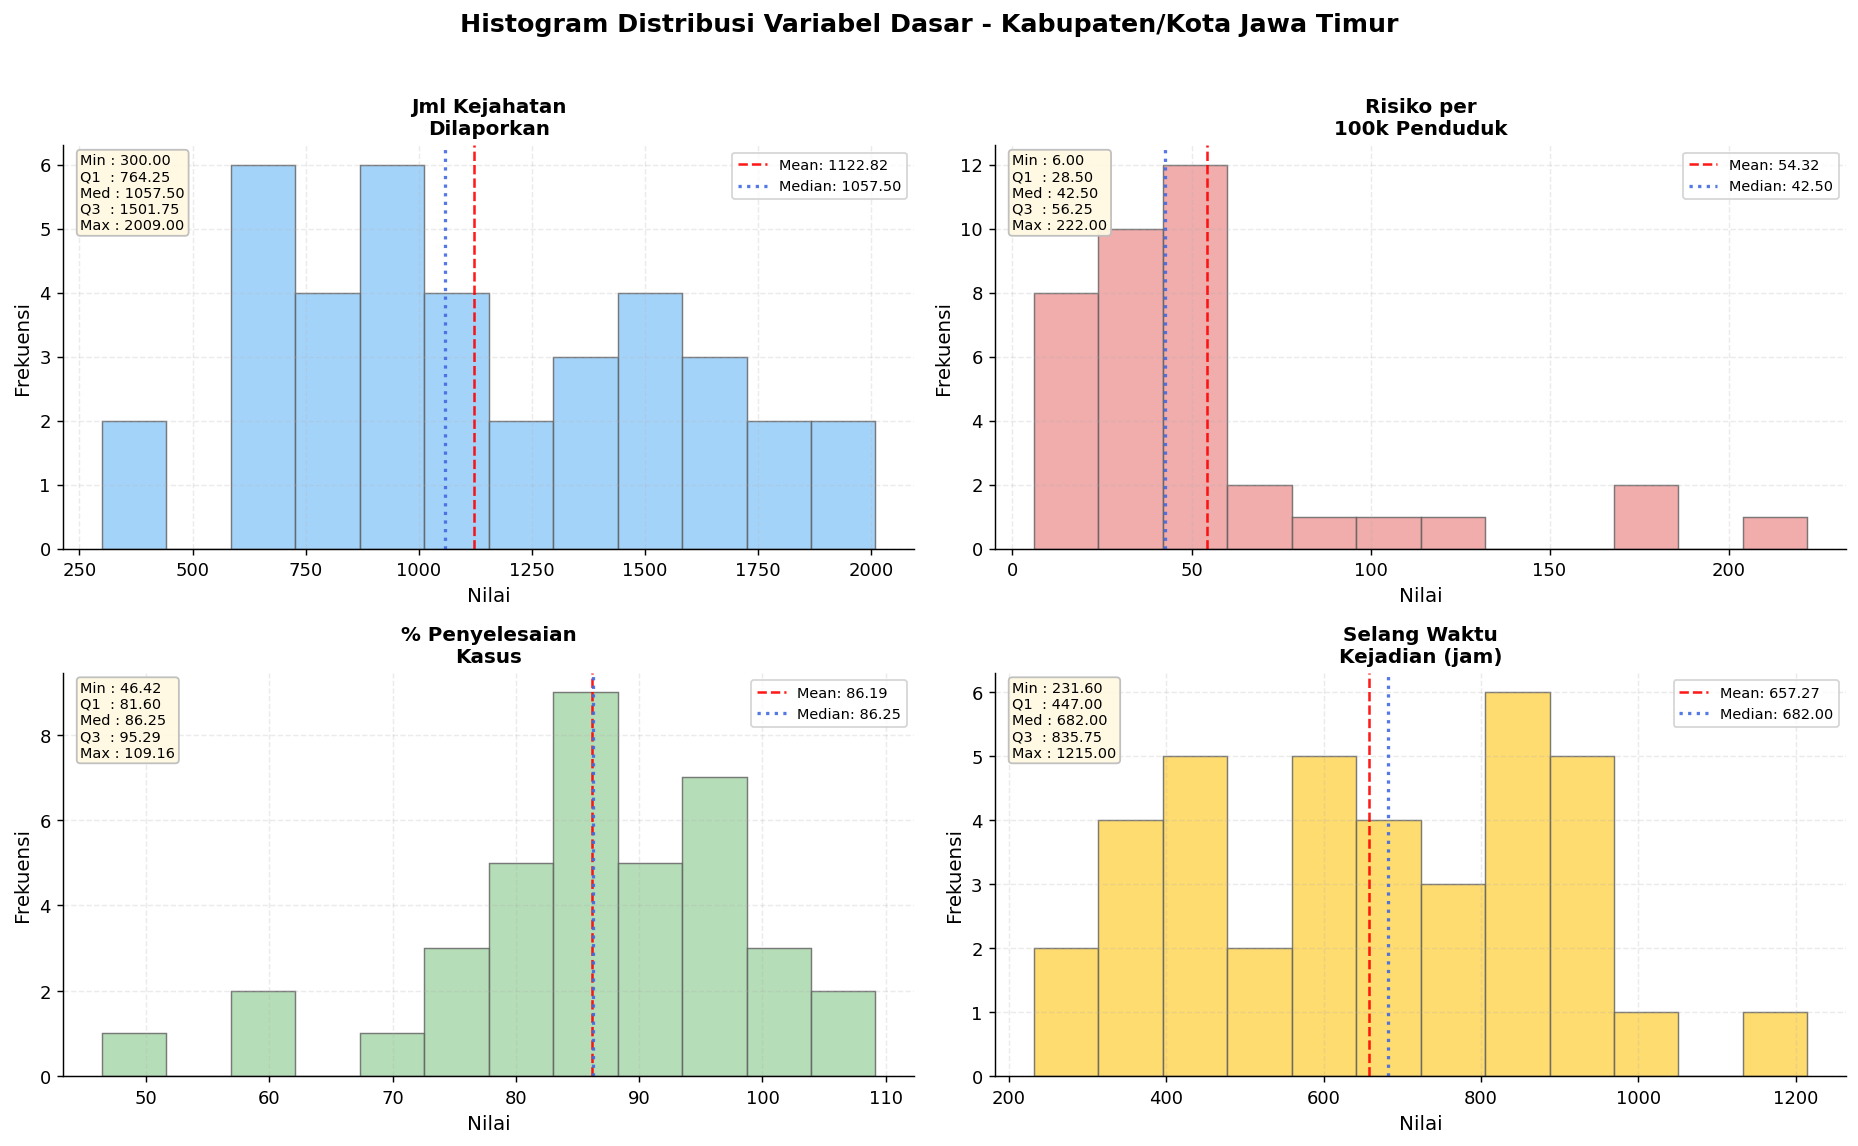

In [5]:
# ── Histogram Distribusi Variabel (gaya dashboard statistik) ──────────────────
hist_cols = FEATURE_COLS.copy()

n_vars = len(hist_cols)
ncols = 2 if n_vars <= 4 else 3
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.3 * nrows))
axes = np.array(axes).reshape(-1)

hist_colors = ['#90CAF9', '#EF9A9A', '#A5D6A7', '#FFD54F', '#CE93D8', '#80CBC4']

for i, col in enumerate(hist_cols):
    ax = axes[i]
    x = df_profile[col].dropna()

    mean_val = x.mean()
    med_val = x.median()
    q1, q3 = x.quantile([0.25, 0.75])
    min_val, max_val = x.min(), x.max()

    ax.hist(
        x,
        bins=12,
        color=hist_colors[i % len(hist_colors)],
        edgecolor='#616161',
        linewidth=0.8,
        alpha=0.82,
    )

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.4, alpha=0.9,
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(med_val, color='royalblue', linestyle=':', linewidth=1.8, alpha=0.9,
               label=f'Median: {med_val:.2f}')

    stats_text = (
        f"Min : {min_val:.2f}\n"
        f"Q1  : {q1:.2f}\n"
        f"Med : {med_val:.2f}\n"
        f"Q3  : {q3:.2f}\n"
        f"Max : {max_val:.2f}"
    )
    ax.text(
        0.02, 0.98, stats_text,
        transform=ax.transAxes,
        fontsize=8,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#FFF8E1', edgecolor='#BDBDBD', alpha=0.95),
    )

    ax.set_title(FEATURE_LABELS.get(col, col), fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.grid(alpha=0.25, linestyle='--')
    ax.legend(loc='upper right', fontsize=8, frameon=True)

for j in range(n_vars, len(axes)):
    axes[j].axis('off')

plt.suptitle('Histogram Distribusi Variabel Dasar - Kabupaten/Kota Jawa Timur',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogram_distribusi_variabel.png', bbox_inches='tight', dpi=130)
plt.show()

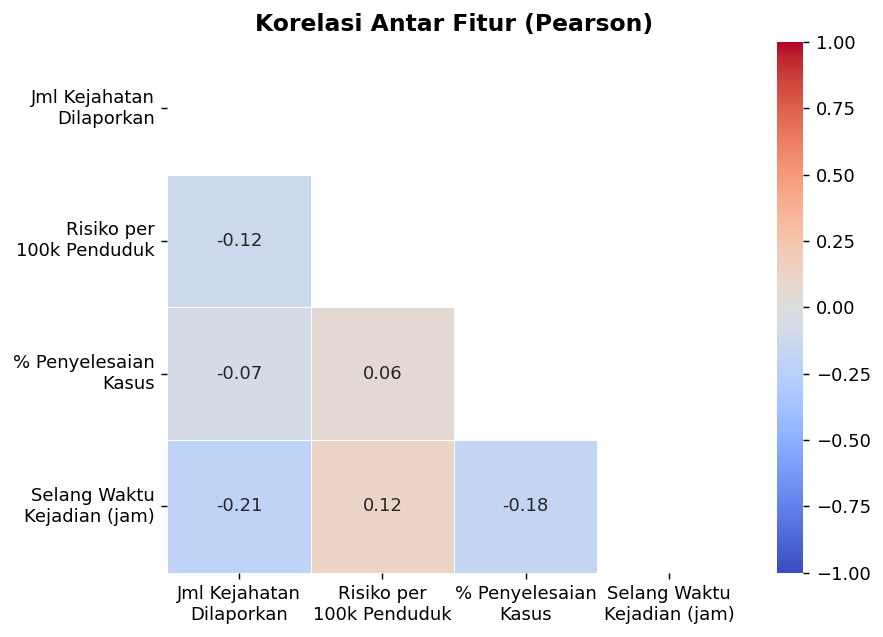

In [6]:
# ── Pearson Correlation Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_profile[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=list(FEATURE_LABELS.values()),
            yticklabels=list(FEATURE_LABELS.values()))
ax.set_title('Korelasi Antar Fitur (Pearson)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', dpi=130)
plt.show()

## 3. Data Preprocessing <a id='3-preprocessing'></a>
### 3.1 Deteksi & Penanganan Outlier — Metode IQR
Nilai ekstrem diidentifikasi dengan batas **IQR × 1.5** dan dikap (*Winsorization*)
agar jumlah Kabupaten/Kota tetap 38 data point.

| Arah Ekstrem | Interpretasi Risiko |
|---|---|
| `Jumlah_Kejahatan` tinggi | Beban kasus besar |
| `Risiko_100k` tinggi | Kerawanan wilayah tinggi |
| `Persen_Penyelesaian` sangat rendah | Kapasitas aparat menurun |
| `Selang_Waktu` sangat pendek | Frekuensi kejadian sangat tinggi |

In [7]:
def detect_and_cap_iqr(df: pd.DataFrame, cols: list) -> tuple[pd.DataFrame, dict]:
    """
    Deteksi outlier IQR dan terapkan Winsorization (capping).
    Returns: (df_clean, report_dict)
    """
    df_out = df.copy()
    report = {}

    for col in cols:
        q1   = df[col].quantile(0.25)
        q3   = df[col].quantile(0.75)
        iqr  = q3 - q1
        lo   = q1 - 1.5 * iqr
        hi   = q3 + 1.5 * iqr

        outlier_idx  = df[(df[col] < lo) | (df[col] > hi)].index
        outlier_kota = df.loc[outlier_idx, 'Kabupaten_Kota'].tolist()

        df_out[col] = df_out[col].clip(lower=lo, upper=hi)
        report[col] = dict(Q1=q1, Q3=q3, IQR=iqr,
                           lower=lo, upper=hi,
                           outliers=outlier_kota,
                           n_outliers=len(outlier_kota))
    return df_out, report


df_clean, iqr_report = detect_and_cap_iqr(df_profile, FEATURE_COLS)

# ── Cetak laporan ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  LAPORAN DETEKSI OUTLIER — METODE IQR (Threshold = 1.5×IQR)")
print("=" * 65)
for col, info in iqr_report.items():
    status = f"⚠️  {info['n_outliers']} daerah" if info['n_outliers'] else "✅ Tidak ada"
    print(f"\n  {col}")
    print(f"    Batas bawah : {info['lower']:>10.2f}  |  Batas atas : {info['upper']:>10.2f}")
    print(f"    Outlier     : {status}")
    if info['outliers']:
        print(f"    Daerah      : {', '.join(info['outliers'])}")

  LAPORAN DETEKSI OUTLIER — METODE IQR (Threshold = 1.5×IQR)

  Jumlah_Kejahatan
    Batas bawah :    -342.00  |  Batas atas :    2608.00
    Outlier     : ✅ Tidak ada

  Risiko_100k
    Batas bawah :     -13.12  |  Batas atas :      97.88
    Outlier     : ⚠️  5 daerah
    Daerah      : Kota Kediri, Kota Mojokerto, Kota Pasuruan, Kota Probolinggo, Magetan

  Persen_Penyelesaian
    Batas bawah :      61.07  |  Batas atas :     115.83
    Outlier     : ⚠️  3 daerah
    Daerah      : Kota Malang, Situbondo, Sumenep

  Selang_Waktu
    Batas bawah :    -136.12  |  Batas atas :    1418.88
    Outlier     : ✅ Tidak ada


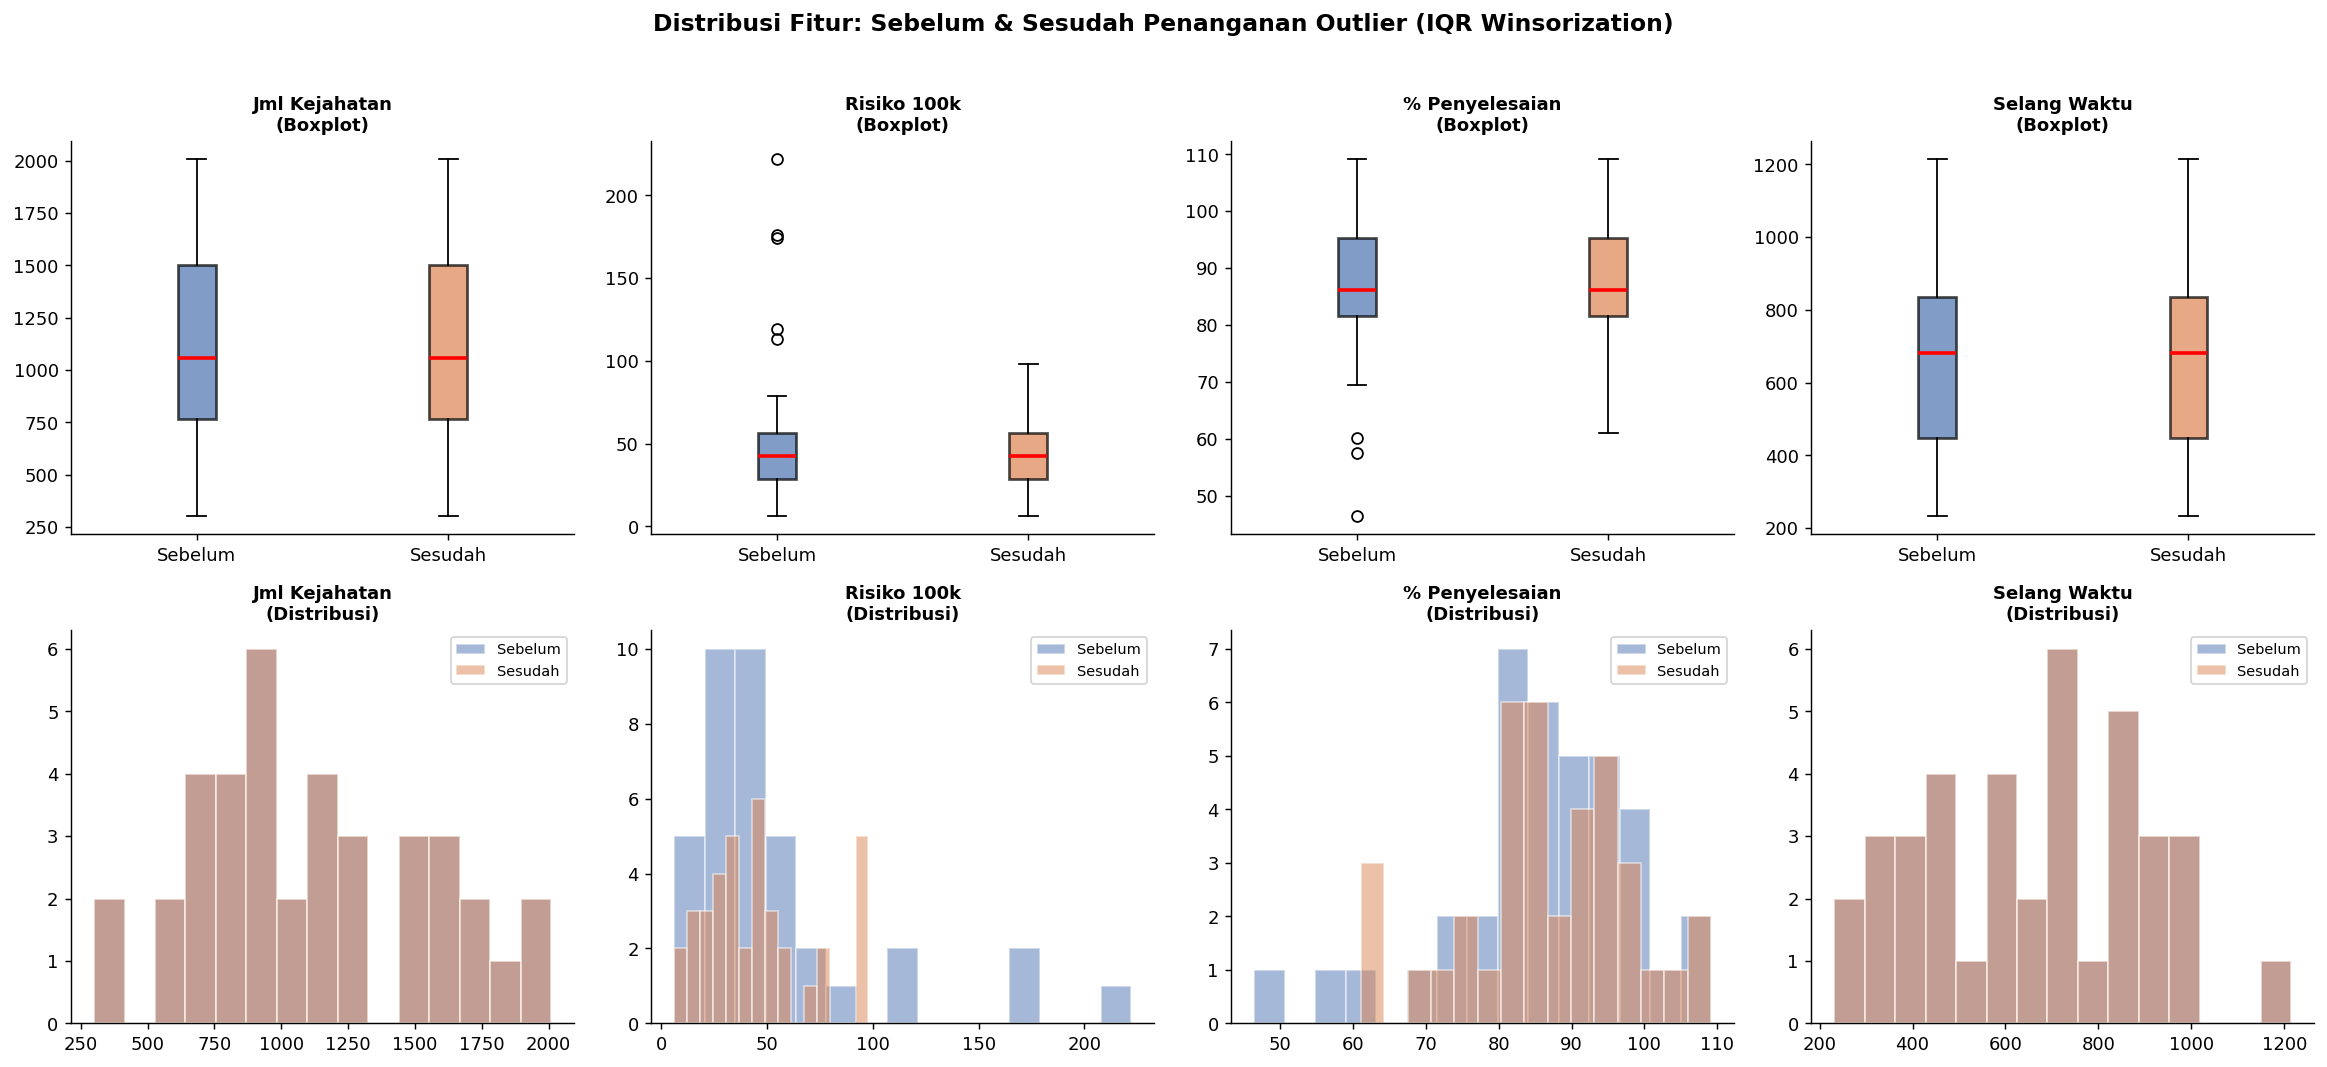

In [8]:
# ── Visualisasi Before vs After Winsorization ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
short_labels = ['Jml Kejahatan', 'Risiko 100k', '% Penyelesaian', 'Selang Waktu']
palette_box  = ['#4C72B0', '#DD8452']

for i, (col, lbl) in enumerate(zip(FEATURE_COLS, short_labels)):
    # Boxplot Before / After
    ax_box = axes[0, i]
    bp = ax_box.boxplot(
        [df_profile[col].dropna().values, df_clean[col].dropna().values],
        labels=['Sebelum', 'Sesudah'], patch_artist=True,
        medianprops=dict(color='red', linewidth=2),
        boxprops=dict(linewidth=1.5),
    )
    for patch, color in zip(bp['boxes'], palette_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_box.set_title(f'{lbl}\n(Boxplot)', fontsize=10, fontweight='bold')

    # Histogram
    ax_hist = axes[1, i]
    ax_hist.hist(df_profile[col].dropna(), bins=15, alpha=0.5,
                 color=palette_box[0], label='Sebelum', edgecolor='white')
    ax_hist.hist(df_clean[col].dropna(), bins=15, alpha=0.5,
                 color=palette_box[1], label='Sesudah', edgecolor='white')
    ax_hist.set_title(f'{lbl}\n(Distribusi)', fontsize=10, fontweight='bold')
    ax_hist.legend(fontsize=8)

fig.suptitle('Distribusi Fitur: Sebelum & Sesudah Penanganan Outlier (IQR Winsorization)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_handling.png', bbox_inches='tight', dpi=130)
plt.show()

### 3.2 Standarisasi Fitur — StandardScaler (Z-Score Normalization)
StandardScaler mengubah setiap fitur menjadi distribusi dengan **mean = 0** dan **std = 1**,
sehingga perbedaan skala antar variabel tidak mendominasi perhitungan jarak cluster.

Verifikasi StandardScaler:
                     Mean (harus ≈ 0)  Std  (harus ≈ 1)
Jumlah_Kejahatan                  0.0               1.0
Risiko_100k                      -0.0               1.0
Persen_Penyelesaian              -0.0               1.0
Selang_Waktu                      0.0               1.0


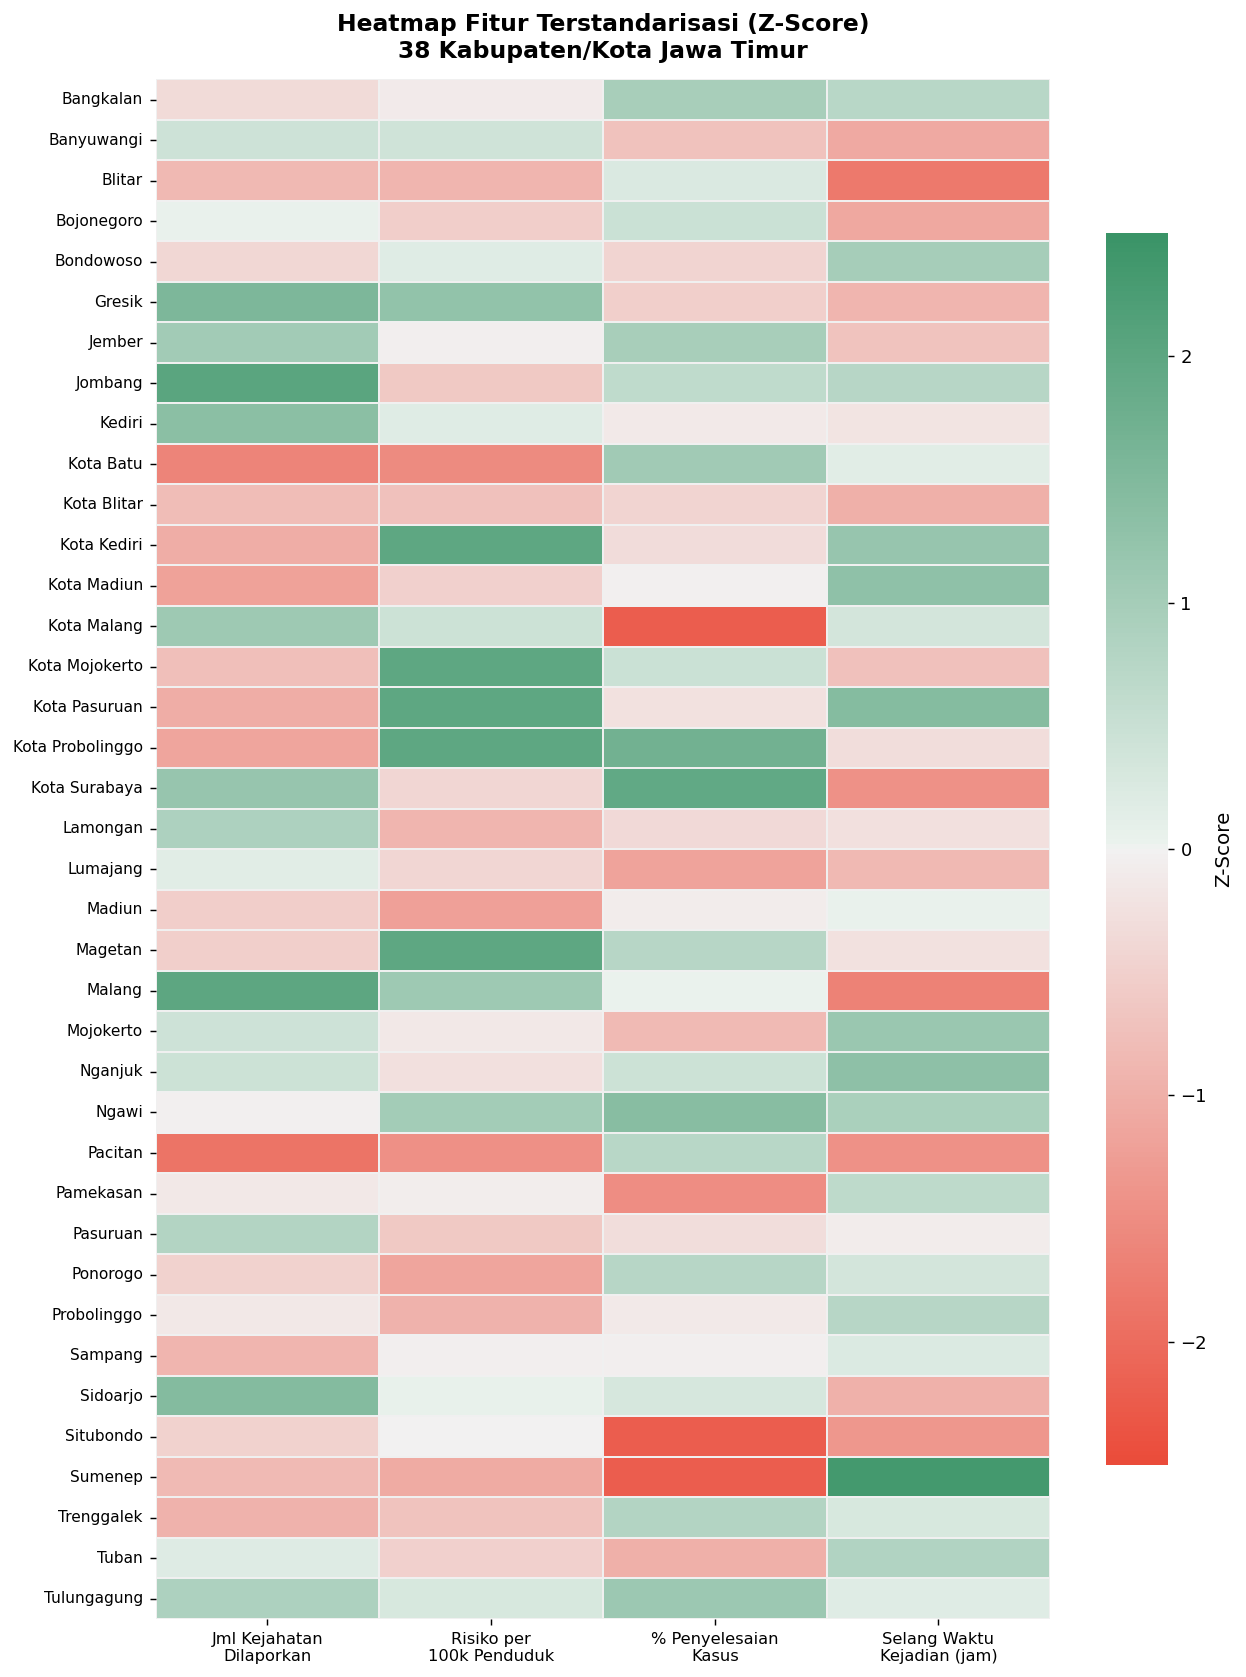

In [9]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURE_COLS])
X_df     = pd.DataFrame(X_scaled, columns=FEATURE_COLS,
                         index=df_clean['Kabupaten_Kota'].values)

print("Verifikasi StandardScaler:")
stat_df = pd.DataFrame({
    'Mean (harus ≈ 0)': X_scaled.mean(axis=0).round(6),
    'Std  (harus ≈ 1)': X_scaled.std(axis=0).round(6),
}, index=FEATURE_COLS)
print(stat_df.to_string())

# ── Heatmap Fitur Terstandarisasi ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 13))
cmap    = sns.diverging_palette(15, 145, s=80, l=55, as_cmap=True)

sns.heatmap(X_df,
            cmap=cmap, center=0, vmin=-2.5, vmax=2.5,
            annot=False, linewidths=0.25, linecolor='#f0f0f0',
            xticklabels=list(FEATURE_LABELS.values()),
            yticklabels=X_df.index, ax=ax,
            cbar_kws={'label': 'Z-Score', 'shrink': 0.8})

ax.set_title('Heatmap Fitur Terstandarisasi (Z-Score)\n38 Kabupaten/Kota Jawa Timur',
             fontweight='bold', pad=12)
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=8.5)
ax.tick_params(axis='x', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('feature_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

## 4. Penentuan Jumlah Cluster Optimal <a id='4-optimal-k'></a>
Validasi jumlah cluster dilakukan dengan **4 metrik sekaligus** dalam satu visual multi-panel.


| Metrik | Arah Optimasi | Fokus Penilaian |
|---|---|---|
| **WCSS (Elbow)** | Lebih rendah lebih baik | Kompaksi intra-cluster |
| **Silhouette** | Lebih tinggi lebih baik | Keseimbangan kompaksi vs separasi |
| **Calinski-Harabasz (CH)** | Lebih tinggi lebih baik | Rasio separasi antar-cluster terhadap dispersi intra-cluster |
| **Davies-Bouldin (DB)** | Lebih rendah lebih baik | Kemiripan antar-cluster (semakin kecil semakin terpisah) |

Tambahan kriteria kebijakan: **minimum anggota per cluster >= 4** agar setiap cluster cukup representatif untuk dasar intervensi kebijakan.
Jika metrik bertentangan, keputusan akhir ditetapkan melalui **tabel keputusan berbobot** dengan filter kelayakan ukuran cluster tersebut.

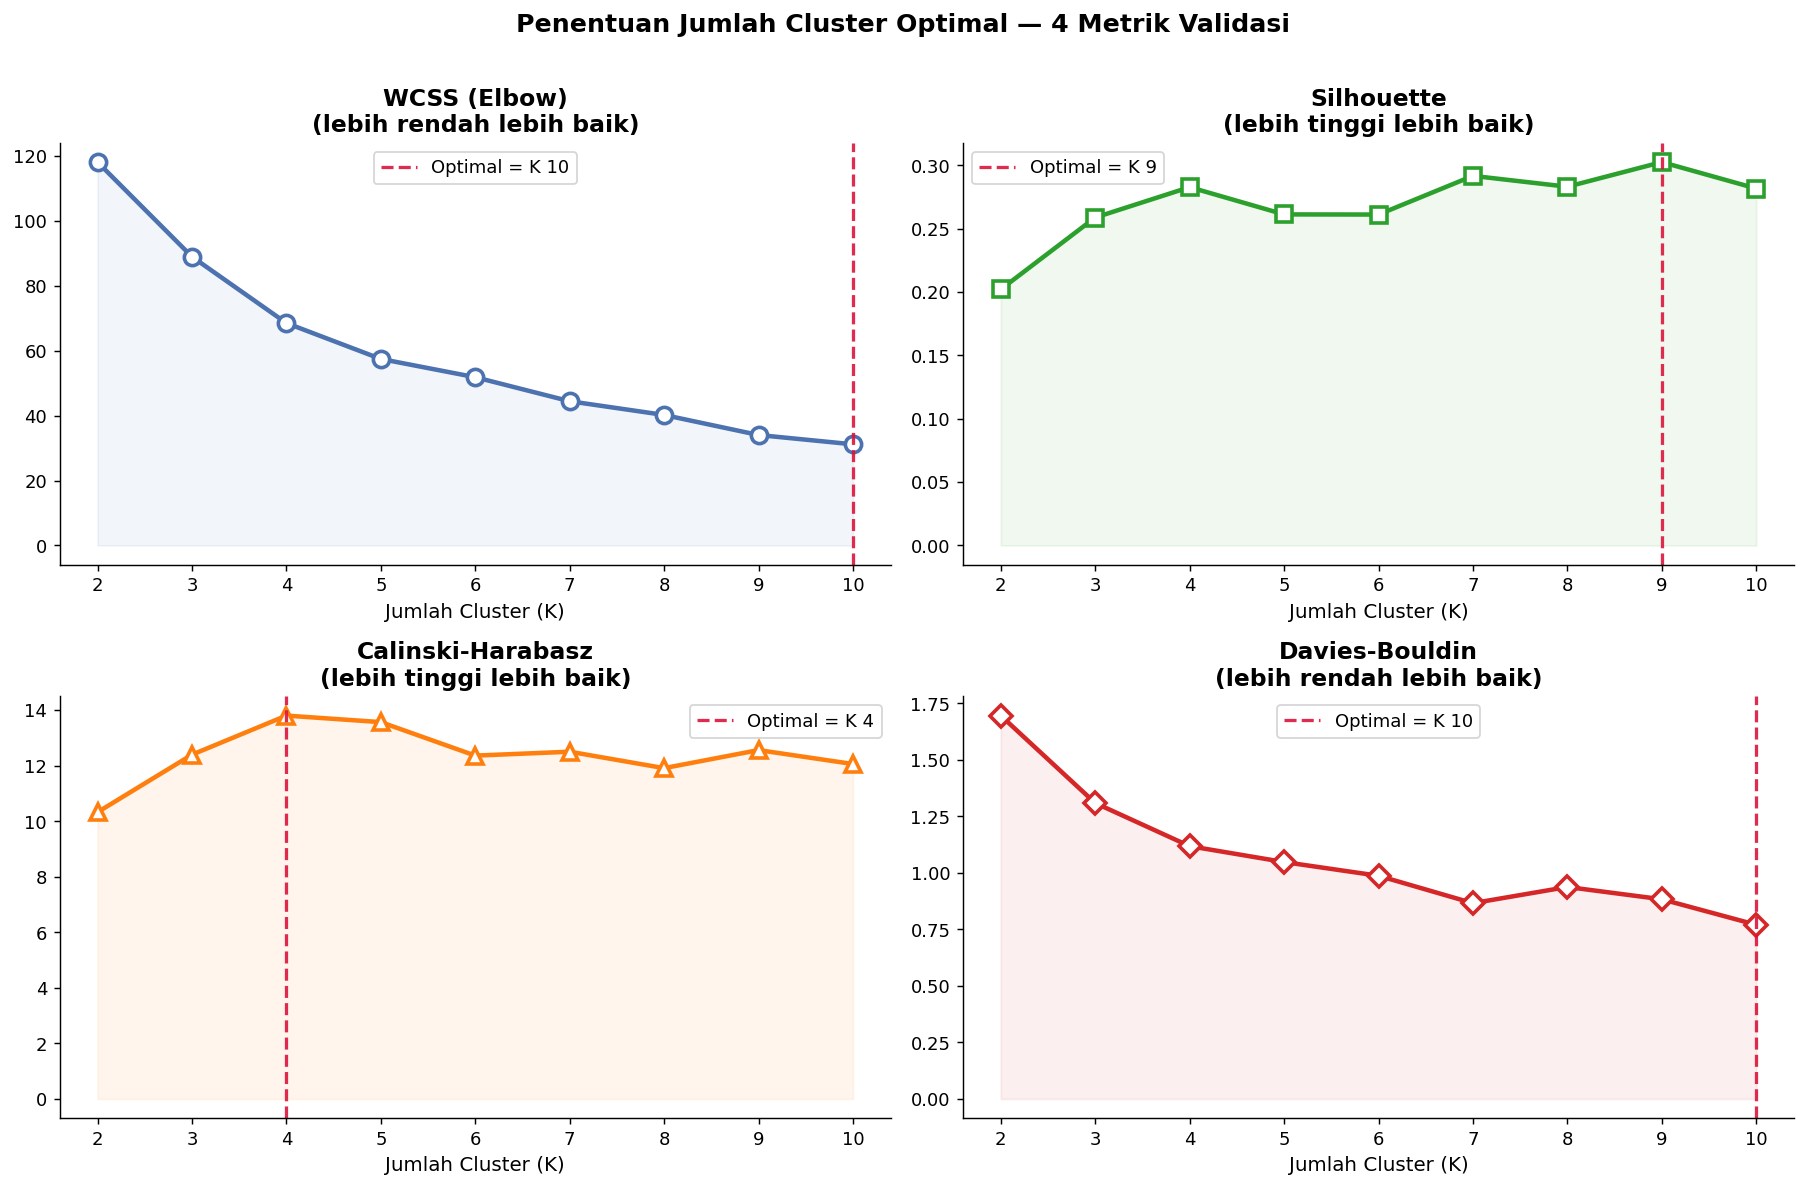


📊 Tabel Keputusan Pemilihan K Optimal:
  Metrik                     Optimal K Keterangan
  -------------------------------------------------------
  WCSS / Elbow                   K = 4   ↓ lebih rendah lebih baik
  Silhouette                     K = 9   ↑ lebih tinggi lebih baik
  Calinski-Harabasz              K = 4   ↑ lebih tinggi lebih baik
  Davies-Bouldin                K = 10   ↓ lebih rendah lebih baik
  -------------------------------------------------------

  K yang paling banyak dipilih metrik : K = 4 (2/4 metrik)
  Status : ⚠️  PERLU PERTIMBANGAN DOMAIN


In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from collections import Counter, defaultdict

K_RANGE    = range(2, 11)
wcss_list  = []
silh_list  = []
ch_list    = []
db_list    = []
cluster_size_rows = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25, max_iter=500)
    labels = km.fit_predict(X_scaled)

    wcss_list.append(km.inertia_)
    silh_list.append(silhouette_score(X_scaled, labels))
    ch_list.append(calinski_harabasz_score(X_scaled, labels))
    db_list.append(davies_bouldin_score(X_scaled, labels))

    counts = pd.Series(labels).value_counts().sort_values()
    cluster_size_rows.append({
        'K': k,
        'Min Anggota': int(counts.min()),
        'Max Anggota': int(counts.max()),
        'Distribusi Ukuran': ', '.join(map(str, counts.tolist())),
        'All_ge_4': bool((counts >= 4).all()),
        'All_ge_5': bool((counts >= 5).all()),
    })

cluster_size_df = pd.DataFrame(cluster_size_rows)
k_ge4 = cluster_size_df.loc[cluster_size_df['All_ge_4'], 'K']
k_ge5 = cluster_size_df.loc[cluster_size_df['All_ge_5'], 'K']
k_ge4_policy = cluster_size_df.loc[(cluster_size_df['K'] >= 4) & (cluster_size_df['All_ge_4']), 'K']

first_k_all_ge4 = int(k_ge4.iloc[0]) if not k_ge4.empty else None
first_k_all_ge5 = int(k_ge5.iloc[0]) if not k_ge5.empty else None
first_k_ge4_policy = int(k_ge4_policy.iloc[0]) if not k_ge4_policy.empty else None

# ── Deteksi K optimal per metrik ─────────────────────────────────────────────
diffs1  = np.diff(wcss_list)
diffs2  = np.diff(diffs1)
elbow_k      = list(K_RANGE)[np.argmax(diffs2) + 1]
best_silh_k  = list(K_RANGE)[np.argmax(silh_list)]
best_ch_k    = list(K_RANGE)[np.argmax(ch_list)]
best_db_k    = list(K_RANGE)[np.argmin(db_list)]

# ── 4-panel figure (WCSS, Silhouette, CH, DB) ───────────────────────────────
metrics = [
    {
        'name': 'WCSS (Elbow)',
        'values': wcss_list,
        'direction': 'min',
        'curve_color': '#4C72B0',
        'vline_color': '#1F4E79',
        'marker': 'o-',
        'winner': elbow_k,
        'weight': 0.20,
        'note': 'Kompaksi intra-cluster',
    },
    {
        'name': 'Silhouette',
        'values': silh_list,
        'direction': 'max',
        'curve_color': '#2CA02C',
        'vline_color': '#1E7A1E',
        'marker': 's-',
        'winner': best_silh_k,
        'weight': 0.40,
        'note': 'Kompaksi vs separasi',
    },
    {
        'name': 'Calinski-Harabasz',
        'values': ch_list,
        'direction': 'max',
        'curve_color': '#FF7F0E',
        'vline_color': '#B85B00',
        'marker': '^-',
        'winner': best_ch_k,
        'weight': 0.20,
        'note': 'Rasio separasi/dispersi',
    },
    {
        'name': 'Davies-Bouldin',
        'values': db_list,
        'direction': 'min',
        'curve_color': '#D62728',
        'vline_color': '#8F1A1B',
        'marker': 'D-',
        'winner': best_db_k,
        'weight': 0.20,
        'note': 'Kemiripan antar-cluster',
    },
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, met in zip(axes.flat, metrics):
    vals = met['values']
    best_k = met['winner']
    direction_label = 'lebih rendah lebih baik' if met['direction'] == 'min' else 'lebih tinggi lebih baik'

    ax.plot(list(K_RANGE), vals, met['marker'], color=met['curve_color'],
            linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(list(K_RANGE), vals, alpha=0.07, color=met['curve_color'])
    ax.axvline(x=best_k, color=met['vline_color'], linestyle='--', linewidth=2.0, alpha=0.95,
               label=f'Optimal = K {best_k}')
    ax.set_title(f"{met['name']}\n({direction_label})", fontweight='bold')
    ax.set_xlabel('Jumlah Cluster (K)')
    ax.legend(fontsize=10)
    ax.set_xticks(list(K_RANGE))

plt.suptitle('Penentuan Jumlah Cluster Optimal — 4 Metrik Validasi',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('optimal_k_4panel.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Output kriteria ukuran cluster (kelayakan kebijakan) ─────────────────────
print("\n📐 Uji Kelayakan Kebijakan: Ukuran Anggota Cluster")
print(cluster_size_df[['K', 'Min Anggota', 'Max Anggota', 'All_ge_4', 'All_ge_5']].to_string(index=False))
print(f"\n  K pertama dengan semua cluster >= 4 anggota (K=2..10): {first_k_all_ge4}")
print(f"  K pertama dengan semua cluster >= 5 anggota (K=2..10): {first_k_all_ge5}")
print(f"  K pertama dengan semua cluster >= 4 anggota untuk segmentasi K>=4: {first_k_ge4_policy}")

# ── Tabel keputusan dengan bobot argumen + syarat minimum anggota ─────────────
print("\n📊 Tabel Keputusan Pemilihan K (per metrik):")
print(f"  {'Metrik':<22} {'Optimal K':>9} {'Bobot':>8}   {'Arah'}")
print(f"  {'-'*70}")
for met in metrics:
    arah = 'min (lebih kecil lebih baik)' if met['direction'] == 'min' else 'max (lebih besar lebih baik)'
    print(f"  {met['name']:<22} {('K='+str(met['winner'])):>9} {met['weight']:>8.2f}   {arah}")
print(f"  {'-'*70}")

vote_counter = Counter(met['winner'] for met in metrics)
weighted_score = defaultdict(float)
supporters = defaultdict(list)
for met in metrics:
    k_win = met['winner']
    weighted_score[k_win] += met['weight']
    supporters[k_win].append(met['name'])

size_min_map = cluster_size_df.set_index('K')['Min Anggota'].to_dict()
feasible_map = cluster_size_df.set_index('K')['All_ge_4'].to_dict()
MIN_POLICY_SIZE = 4

decision_rows = []
for k in K_RANGE:
    decision_rows.append({
        'K': k,
        'Jumlah Vote': vote_counter.get(k, 0),
        'Skor Bobot': weighted_score.get(k, 0.0),
        f'Layak Kebijakan (>={MIN_POLICY_SIZE})': bool(feasible_map.get(k, False)),
        'Min Anggota': int(size_min_map.get(k, 0)),
        'Metrik Pendukung': ', '.join(supporters.get(k, [])) if supporters.get(k, []) else '-',
    })

decision_df = pd.DataFrame(decision_rows).sort_values(
    by=[f'Layak Kebijakan (>={MIN_POLICY_SIZE})', 'Skor Bobot', 'Jumlah Vote', 'K'],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("\n📌 Tabel Keputusan Berbobot + Kelayakan Kebijakan:")
print(decision_df.to_string(index=False, formatters={'Skor Bobot': '{:.2f}'.format}))

votes = [met['winner'] for met in metrics]
all_agree = len(set(votes)) == 1

policy_pool = decision_df[decision_df[f'Layak Kebijakan (>={MIN_POLICY_SIZE})']].copy()
policy_constraint_active = not policy_pool.empty
if not policy_constraint_active:
    policy_pool = decision_df.copy()

if all_agree and (int(votes[0]) in policy_pool['K'].tolist()):
    OPTIMAL_K = int(votes[0])
    decision_note = f"Semua metrik sepakat pada K={OPTIMAL_K}; keputusan sangat defensible secara statistik."
elif vote_counter.get(4, 0) >= 3:
    OPTIMAL_K = 4
    decision_note = (
        "3 dari 4 metrik memilih K=4; OPTIMAL_K ditetapkan ke 4 sebagai trade-off "
        "antara granularitas kebijakan dan stabilitas statistik."
    )
else:
    top_score = float(policy_pool['Skor Bobot'].max())
    top_candidates = policy_pool[np.isclose(policy_pool['Skor Bobot'], top_score)].copy()
    top_vote = int(top_candidates['Jumlah Vote'].max())
    top_candidates = top_candidates[top_candidates['Jumlah Vote'] == top_vote]
    candidate_ks = sorted(top_candidates['K'].astype(int).tolist())

    constraint_prefix = (
        f"Seleksi dibatasi pada K dengan minimum {MIN_POLICY_SIZE} anggota per cluster. "
        if policy_constraint_active
        else f"Tidak ada K yang memenuhi minimum {MIN_POLICY_SIZE}; seleksi kembali ke semua kandidat. "
    )

    if len(candidate_ks) == 1:
        OPTIMAL_K = candidate_ks[0]
        decision_note = (
            f"{constraint_prefix}Dipilih K={OPTIMAL_K} berdasarkan skor bobot tertinggi "
            f"({top_score:.2f}) dan dukungan metrik terbanyak ({top_vote} vote)."
        )
    else:
        if best_silh_k in candidate_ks:
            OPTIMAL_K = int(best_silh_k)
            tie_rule = 'tie diselesaikan dengan prioritas metrik Silhouette'
        else:
            OPTIMAL_K = int(min(candidate_ks))
            tie_rule = 'tie diselesaikan dengan memilih K yang lebih ringkas'
        decision_note = (
            f"{constraint_prefix}Skor bobot seri pada K={candidate_ks}; {tie_rule}, "
            f"sehingga dipilih K={OPTIMAL_K}."
        )

min_size_selected = int(size_min_map.get(OPTIMAL_K, 0))
print(f"\n🎯 Jumlah Cluster yang Digunakan: K = {OPTIMAL_K}")
print(f"👥 Minimum anggota cluster pada K terpilih: {min_size_selected}")
print(f"📝 Argumen Keputusan: {decision_note}")

print("\nRingkasan pemenang per metrik:")
for met in metrics:
    print(f"  - {met['name']:<20} -> K = {met['winner']} (bobot {met['weight']:.2f})")

### 4.3 Justifikasi Eksplisit Pemilihan K dengan Kriteria Kelayakan Kebijakan

Keputusan K tidak hanya berdasarkan metrik validasi internal, tetapi juga **kelayakan ukuran cluster** untuk implementasi kebijakan.


| K | Silhouette | Calinski-Harabasz | Davies-Bouldin | Min Anggota Cluster | Layak Kebijakan (>=4 anggota) |
|---|---:|---:|---:|---:|:---:|
| 2  | 0.2022 | 10.3293 | 1.6959 | 16 | Ya |
| 3  | 0.2589 | 12.4007 | 1.3091 | 6  | Ya |
| 4  | 0.2829 | **13.8082** | 1.1184 | 6  | Ya |
| 5  | 0.2614 | 13.5736 | 1.0480 | 4  | Ya |
| 6  | 0.2613 | 12.3669 | 0.9874 | 2  | Tidak |
| 7  | 0.2918 | 12.5074 | 0.8661 | 2  | Tidak |
| 8  | 0.2832 | 11.9158 | 0.9377 | 2  | Tidak |
| 9  | **0.3027** | 12.5661 | 0.8834 | 2  | Tidak |
| 10 | 0.2818 | 12.0636 | **0.7705** | 1  | Tidak |

Ringkasan keputusan:
- Pemenang metrik berbeda: Elbow = 4, Silhouette = 9, CH = 4, DB = 10.
- K pertama yang memenuhi syarat semua cluster >=4 pada rentang K=2..10 adalah **K=2** (terlalu kasar untuk segmentasi kebijakan rinci).
- Untuk segmentasi kebijakan yang tetap granular (K>=4), K pertama yang memenuhi syarat adalah **K=4**.
- Karena K=9 memiliki cluster minimum 2 anggota, K=9 **tidak layak** dijadikan basis kebijakan langsung tanpa tahap validasi tambahan.

Implikasi pemilihan:
- K dipilih dari kandidat yang lolos syarat minimum anggota cluster, lalu dievaluasi dengan bobot metrik.
- Dengan kriteria tersebut, keputusan operasional diarahkan ke **K=4** sebagai trade-off antara granularitas dan stabilitas statistik.

Catatan jika K=9 tetap dipakai (analisis eksploratif):
- Cluster dengan 2 anggota harus diperlakukan sebagai **kasus khusus** yang wajib verifikasi lapangan.
- Hasil cluster kecil tidak digunakan langsung untuk kebijakan makro (redistribusi personel/anggaran) sebelum validasi tambahan.


🎯 Jumlah Cluster yang Digunakan: K = 9


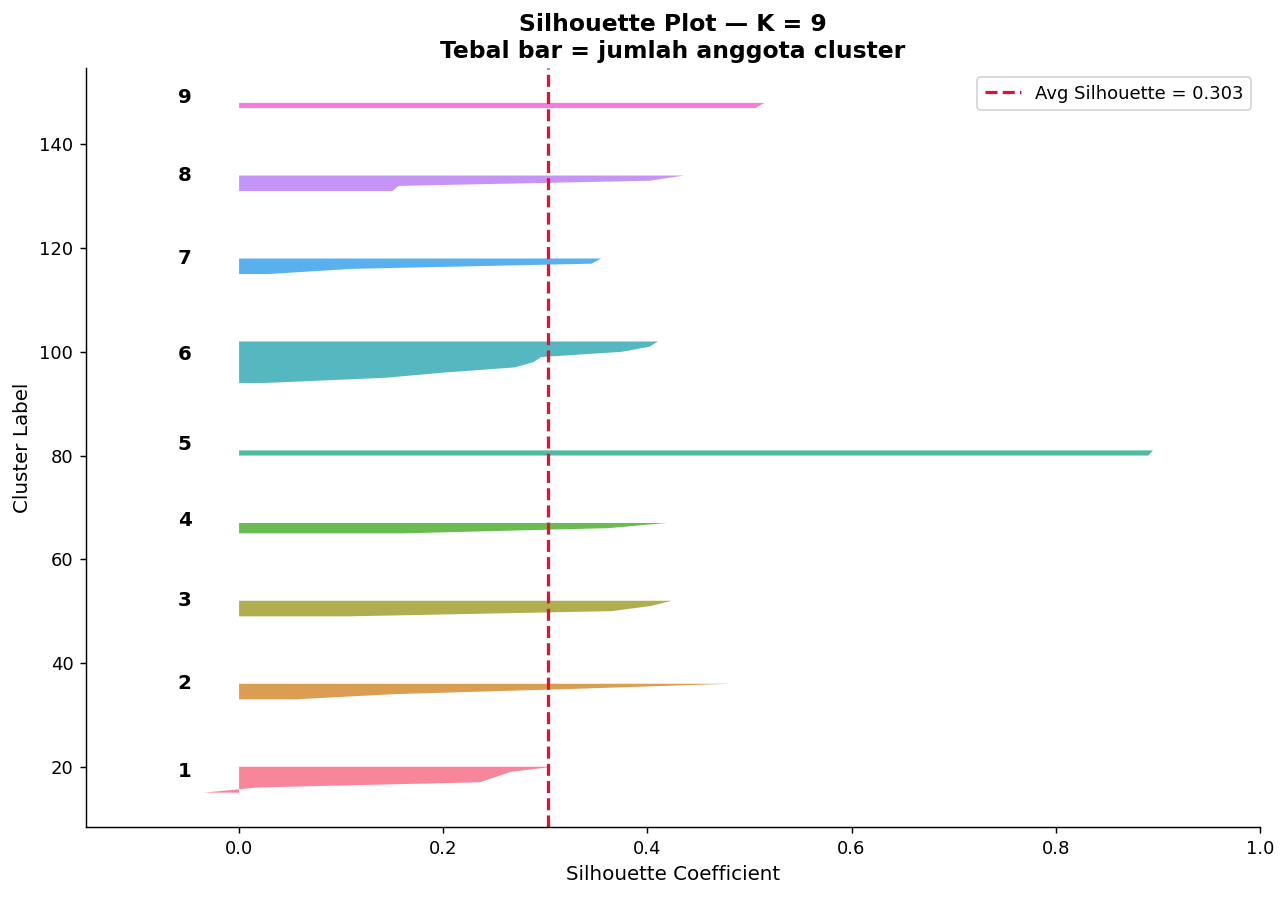

In [ ]:
# ── Gunakan K hasil keputusan berbobot pada Section 4 ────────────────────────
print(f"\n🎯 Jumlah Cluster yang Digunakan: K = {OPTIMAL_K}")
if 'decision_note' in globals():
    print(f"📝 Argumen Keputusan: {decision_note}")

# ── Silhouette Plot Detail untuk OPTIMAL_K ────────────────────────────────────
km_tmp    = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=25)
lbl_tmp   = km_tmp.fit_predict(X_scaled)
silh_vals = silhouette_samples(X_scaled, lbl_tmp)
avg_silh  = silhouette_score(X_scaled, lbl_tmp)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower  = 15
col_list = sns.color_palette('husl', OPTIMAL_K)

for i in range(OPTIMAL_K):
    ith  = np.sort(silh_vals[lbl_tmp == i])
    y_upper = y_lower + len(ith)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=col_list[i], edgecolor='none', alpha=0.85)
    ax.text(-0.06, y_lower + 0.5 * len(ith), str(i + 1), fontsize=11, fontweight='bold')
    y_lower = y_upper + 12

ax.axvline(x=avg_silh, color='crimson', linestyle='--', linewidth=1.8,
           label=f'Avg Silhouette = {avg_silh:.3f}')
ax.set_xlim([-0.15, 1.0])
ax.set_title(f'Silhouette Plot — K = {OPTIMAL_K}\nTebal bar = jumlah anggota cluster',
             fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster Label')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('silhouette_detail.png', bbox_inches='tight', dpi=130)
plt.show()

## 5. K-Means Clustering <a id='5-kmeans'></a>
K-Means meminimalkan **WCSS** dengan memperbarui centroid secara iteratif.
Dijalankan dengan `n_init=25` untuk menghindari konvergensi ke local optimum.

In [12]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE,
                n_init=25, max_iter=500)
df_clean = df_clean.copy()
df_clean['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

silh_km = silhouette_score(X_scaled, df_clean['Cluster_KMeans'])
print(f"K-Means Silhouette Score  : {silh_km:.4f}")
print(f"K-Means WCSS (Inertia)    : {kmeans.inertia_:.2f}")
print(f"Iterasi (Konvergensi)     : {kmeans.n_iter_}")
print()
print("┌─────────────────────────────────────────────────────────────────────┐")
print("  ANGGOTA CLUSTER — K-MEANS")
print("└─────────────────────────────────────────────────────────────────────┘")
for cl_id in sorted(df_clean['Cluster_KMeans'].unique()):
    members = df_clean[df_clean['Cluster_KMeans'] == cl_id]['Kabupaten_Kota'].tolist()
    print(f"  Cluster {cl_id + 1:>2} ({len(members):>2} daerah): {', '.join(members)}")

K-Means Silhouette Score  : 0.3027
K-Means WCSS (Inertia)    : 34.03
Iterasi (Konvergensi)     : 5

┌─────────────────────────────────────────────────────────────────────┐
  ANGGOTA CLUSTER — K-MEANS
└─────────────────────────────────────────────────────────────────────┘
  Cluster  1 ( 6 daerah): Bondowoso, Kota Malang, Mojokerto, Pamekasan, Sumenep, Tuban
  Cluster  2 ( 4 daerah): Blitar, Bojonegoro, Kota Blitar, Pacitan
  Cluster  3 ( 4 daerah): Kota Mojokerto, Kota Probolinggo, Magetan, Ngawi
  Cluster  4 ( 3 daerah): Banyuwangi, Lumajang, Situbondo
  Cluster  5 ( 2 daerah): Kota Kediri, Kota Pasuruan
  Cluster  6 ( 9 daerah): Bangkalan, Kota Batu, Kota Madiun, Madiun, Nganjuk, Ponorogo, Probolinggo, Sampang, Trenggalek
  Cluster  7 ( 4 daerah): Jember, Kota Surabaya, Sidoarjo, Tulungagung
  Cluster  8 ( 4 daerah): Jombang, Kediri, Lamongan, Pasuruan
  Cluster  9 ( 2 daerah): Gresik, Malang


## 6. Ward's Hierarchical Clustering <a id='6-hierarchical'></a>
### 6.1 Dendrogram
Dendrogram menampilkan hierarki penggabungan cluster dari bawah ke atas.
**Ward's Linkage** meminimalkan varians total dalam cluster saat penggabungan.

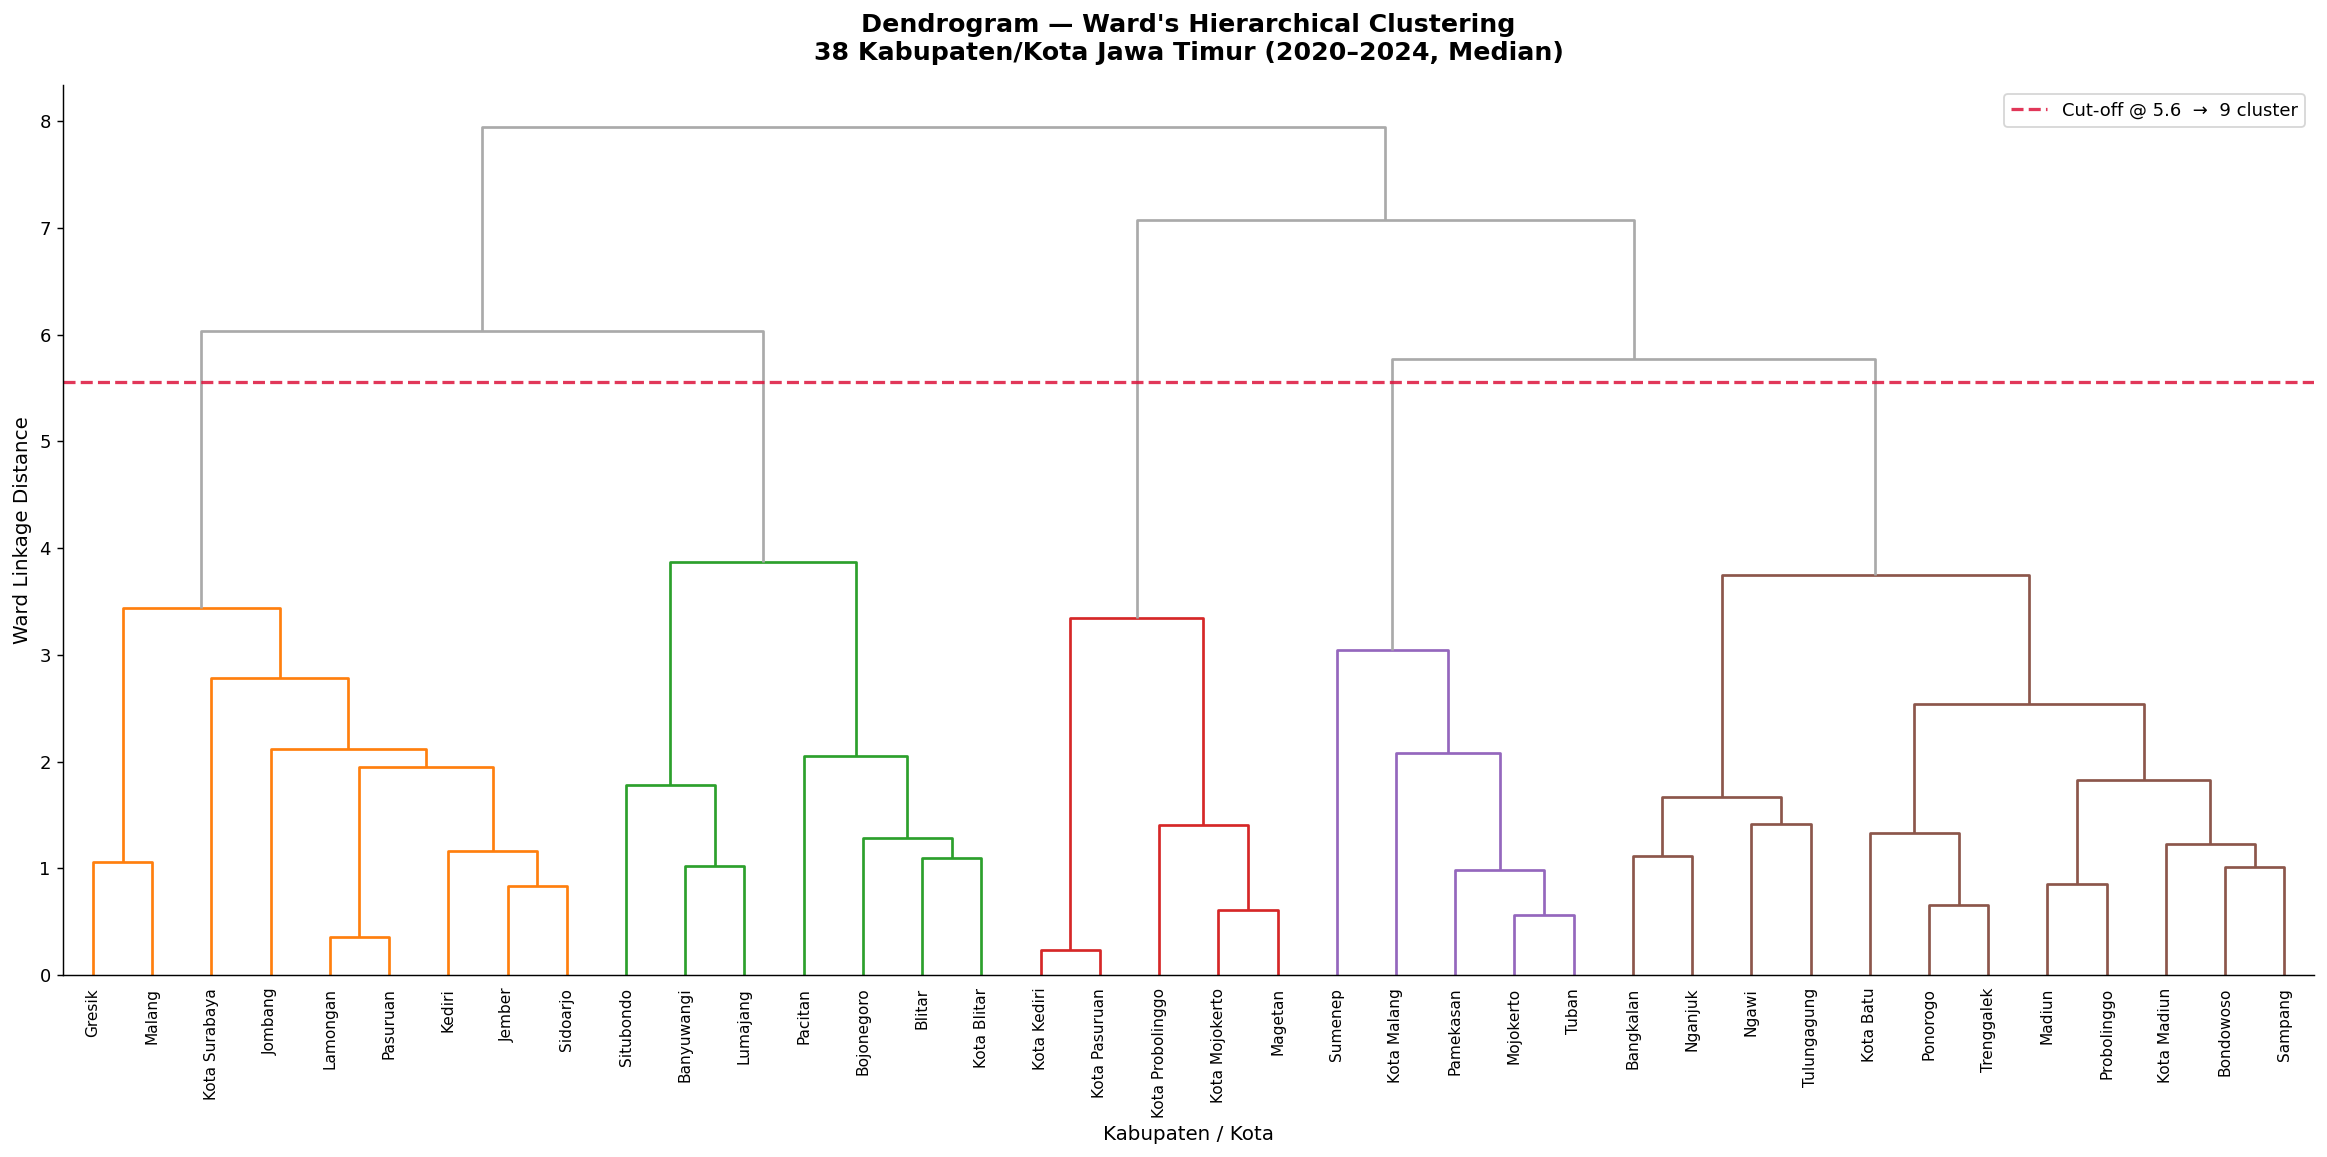

In [13]:
# ── Hitung Ward Linkage Matrix ────────────────────────────────────────────────
Z_ward = linkage(X_scaled, method='ward', metric='euclidean')

# ── Ambang potong otomatis (70% dari jarak maksimum) ─────────────────────────
threshold = 0.70 * max(Z_ward[:, 2])

fig, ax = plt.subplots(figsize=(18, 9))
dendrogram(
    Z_ward,
    labels      = df_clean['Kabupaten_Kota'].values,
    orientation = 'top',
    leaf_rotation  = 90,
    leaf_font_size = 8.5,
    color_threshold = threshold,
    above_threshold_color = '#AAAAAA',
    ax = ax,
)
ax.axhline(y=threshold, color='crimson', linestyle='--', linewidth=1.8, alpha=0.85,
           label=f'Cut-off @ {threshold:.1f}  →  {OPTIMAL_K} cluster')
ax.set_title(
    "Dendrogram — Ward's Hierarchical Clustering\n38 Kabupaten/Kota Jawa Timur (2020–2024, Median)",
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Kabupaten / Kota', fontsize=11)
ax.set_ylabel('Ward Linkage Distance', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight', dpi=130)
plt.show()

### 6.2 Penerapan Hierarchical Clustering & Validasi Silang

In [14]:
# ── Terapkan AgglomerativeClustering ─────────────────────────────────────────
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df_clean['Cluster_HC'] = hc.fit_predict(X_scaled)

silh_hc = silhouette_score(X_scaled, df_clean['Cluster_HC'])
print(f"Hierarchical (Ward) Silhouette Score : {silh_hc:.4f}")

# ── Adjusted Rand Index — kesepakatan dua metode ─────────────────────────────
ari = adjusted_rand_score(df_clean['Cluster_KMeans'], df_clean['Cluster_HC'])
print(f"Adjusted Rand Index (K-Means vs HC)   : {ari:.4f}")
print("  (ARI = 1.0 → identik sempurna | 0.0 → tidak ada kesepakatan)")

print()
print("┌─────────────────────────────────────────────────────────────────────┐")
print("  ANGGOTA CLUSTER — WARD'S HIERARCHICAL")
print("└─────────────────────────────────────────────────────────────────────┘")
for cl_id in sorted(df_clean['Cluster_HC'].unique()):
    members = df_clean[df_clean['Cluster_HC'] == cl_id]['Kabupaten_Kota'].tolist()
    print(f"  Cluster {cl_id + 1:>2} ({len(members):>2} daerah): {', '.join(members)}")

Hierarchical (Ward) Silhouette Score : 0.2935
Adjusted Rand Index (K-Means vs HC)   : 0.6525
  (ARI = 1.0 → identik sempurna | 0.0 → tidak ada kesepakatan)

┌─────────────────────────────────────────────────────────────────────┐
  ANGGOTA CLUSTER — WARD'S HIERARCHICAL
└─────────────────────────────────────────────────────────────────────┘
  Cluster  1 ( 5 daerah): Kota Malang, Mojokerto, Pamekasan, Sumenep, Tuban
  Cluster  2 ( 8 daerah): Bondowoso, Kota Batu, Kota Madiun, Madiun, Ponorogo, Probolinggo, Sampang, Trenggalek
  Cluster  3 ( 7 daerah): Jember, Jombang, Kediri, Kota Surabaya, Lamongan, Pasuruan, Sidoarjo
  Cluster  4 ( 4 daerah): Blitar, Bojonegoro, Kota Blitar, Pacitan
  Cluster  5 ( 3 daerah): Kota Mojokerto, Kota Probolinggo, Magetan
  Cluster  6 ( 3 daerah): Banyuwangi, Lumajang, Situbondo
  Cluster  7 ( 4 daerah): Bangkalan, Nganjuk, Ngawi, Tulungagung
  Cluster  8 ( 2 daerah): Gresik, Malang
  Cluster  9 ( 2 daerah): Kota Kediri, Kota Pasuruan


In [15]:
# ── Tabel perbandingan keanggotaan ────────────────────────────────────────────
comparison = df_clean[['Kabupaten_Kota', 'Cluster_KMeans', 'Cluster_HC']].copy()
comparison['Cluster_KMeans_Label'] = comparison['Cluster_KMeans'] + 1
comparison['Cluster_HC_Label']     = comparison['Cluster_HC'] + 1
comparison['Kesepakatan']          = (comparison['Cluster_KMeans'] == comparison['Cluster_HC']).map(
    {True: '✅', False: '⚠️ Beda'}
)

# Confusion Matrix K-Means vs HC
from pandas import crosstab
cm_df = crosstab(comparison['Cluster_KMeans_Label'],
                 comparison['Cluster_HC_Label'],
                 rownames=['K-Means'], colnames=['Hierarchical'])
print("\nConfusion Matrix Keanggotaan Cluster:")
print(cm_df.to_string())


Confusion Matrix Keanggotaan Cluster:
Hierarchical  1  2  3  4  5  6  7  8  9
K-Means                                
1             5  1  0  0  0  0  0  0  0
2             0  0  0  4  0  0  0  0  0
3             0  0  0  0  3  0  1  0  0
4             0  0  0  0  0  3  0  0  0
5             0  0  0  0  0  0  0  0  2
6             0  7  0  0  0  0  2  0  0
7             0  0  3  0  0  0  1  0  0
8             0  0  4  0  0  0  0  0  0
9             0  0  0  0  0  0  0  2  0


## 7. Visualisasi PCA 2D <a id='7-pca'></a>
PCA (Principal Component Analysis) mereduksi dimensi 4D → 2D untuk visualisasi.
Setiap titik mewakili satu Kabupaten/Kota; warna menunjukkan cluster.

In [16]:
pca  = PCA(n_components=2, random_state=RANDOM_STATE)
X_pc = pca.fit_transform(X_scaled)

ev1, ev2 = pca.explained_variance_ratio_
total_ev  = ev1 + ev2
print(f"Explained Variance  →  PC1: {ev1:.2%}  |  PC2: {ev2:.2%}  |  Total: {total_ev:.2%}")
print()
print("Kontribusi Fitur terhadap PC1 & PC2:")
loading_df = pd.DataFrame(
    pca.components_.T,
    index   = list(FEATURE_LABELS.values()),
    columns = ['PC1 Loading', 'PC2 Loading']
).round(3)
print(loading_df.to_string())

Explained Variance  →  PC1: 31.91%  |  PC2: 26.23%  |  Total: 58.13%

Kontribusi Fitur terhadap PC1 & PC2:
                              PC1 Loading  PC2 Loading
Jml Kejahatan\nDilaporkan          -0.510       -0.675
Risiko per\n100k Penduduk          -0.259        0.034
% Penyelesaian\nKasus              -0.454        0.737
Selang Waktu\nKejadian (jam)        0.683       -0.001


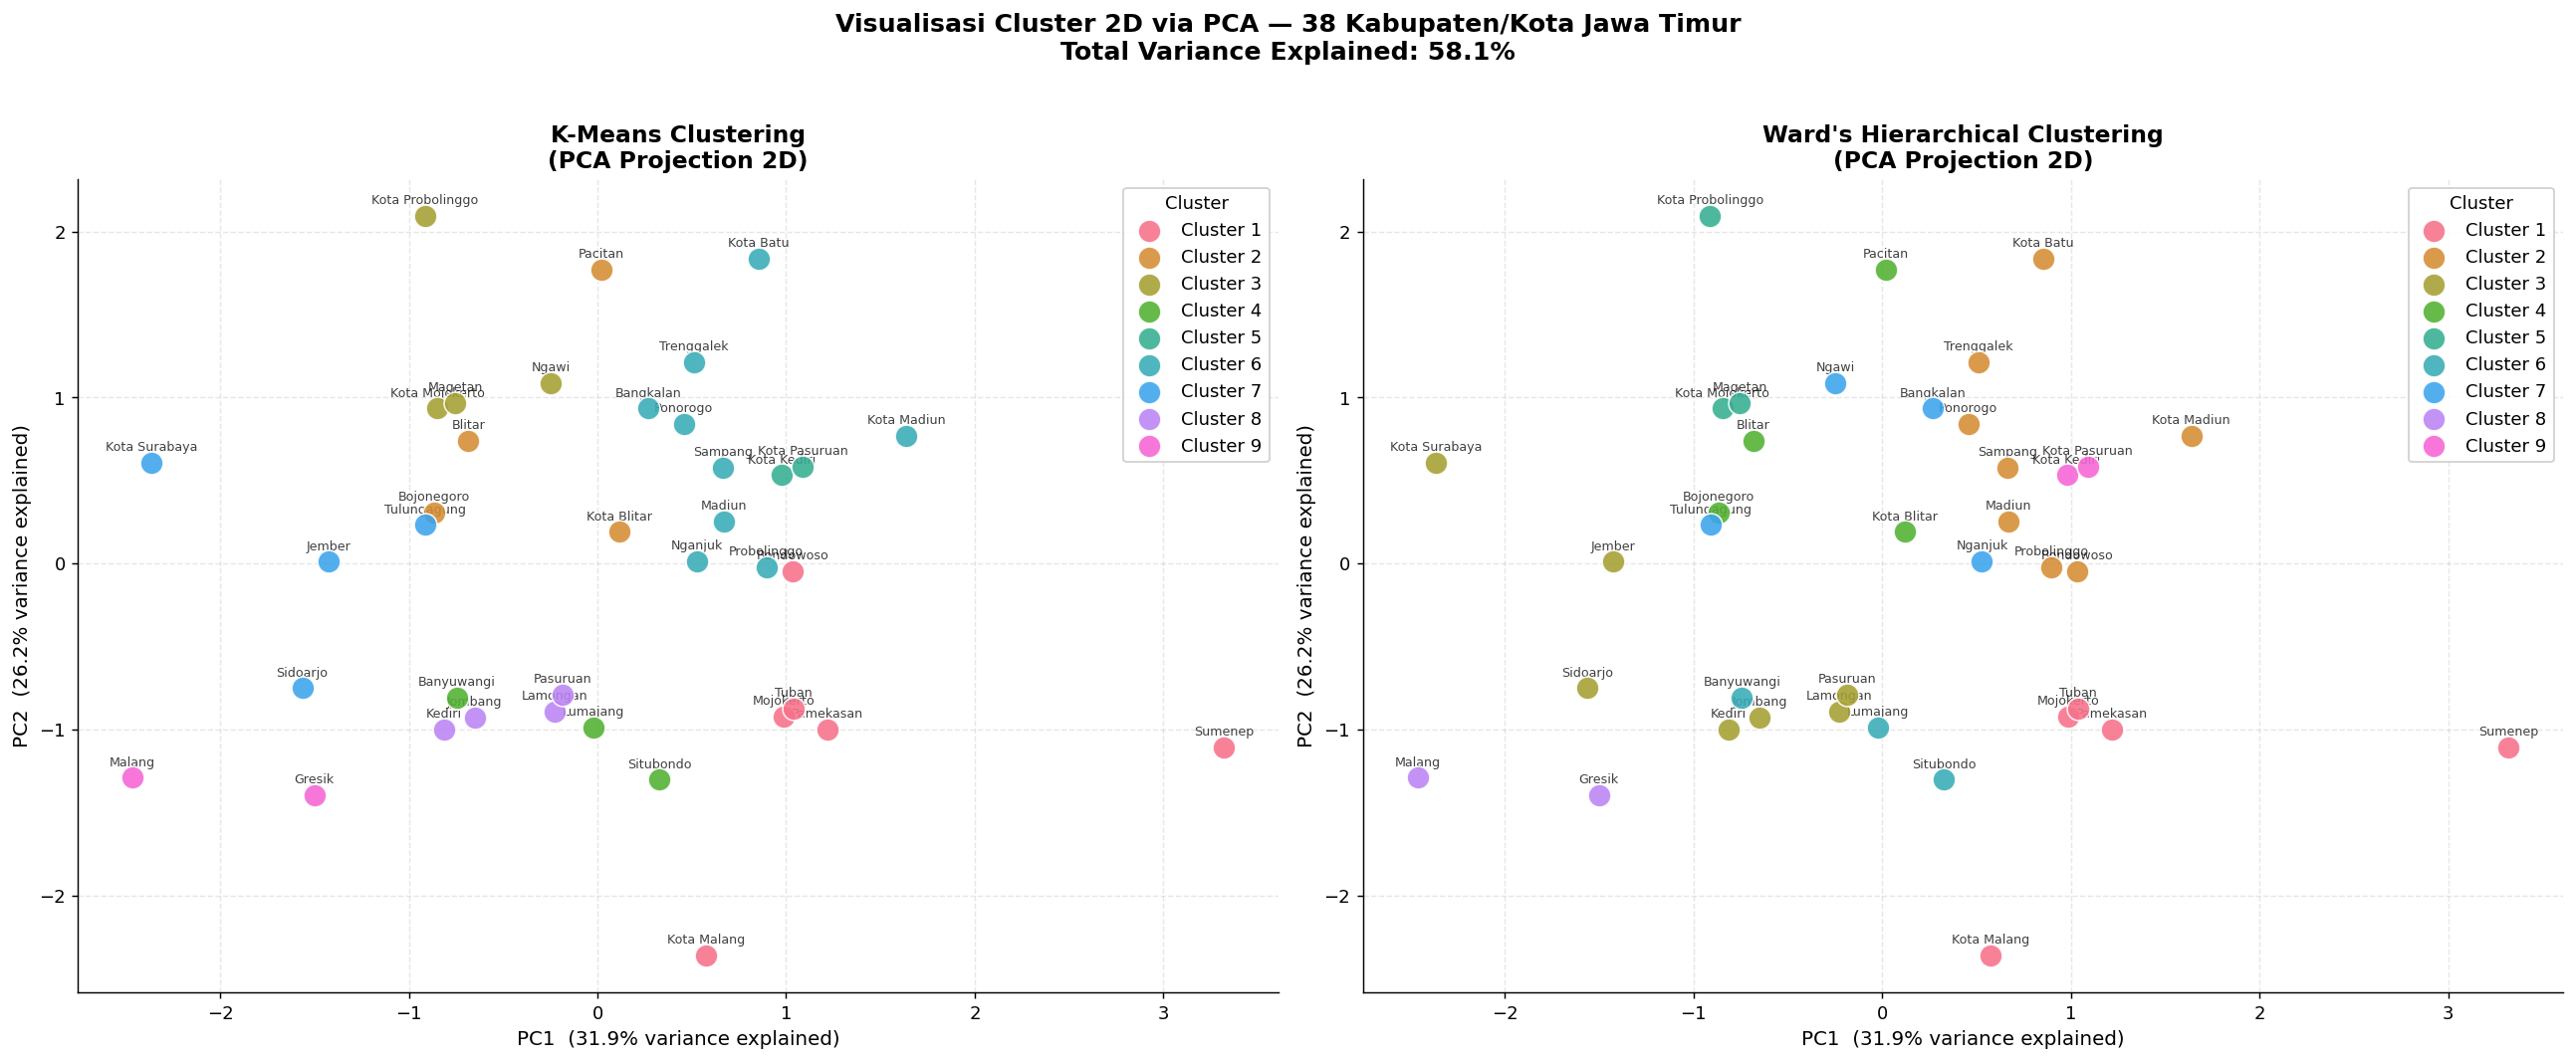

In [17]:
# ── Matplotlib: K-Means vs Hierarchical — Side-by-side ───────────────────────
col_list = sns.color_palette('husl', OPTIMAL_K)
titles   = ['K-Means Clustering', "Ward's Hierarchical Clustering"]
cluster_cols = ['Cluster_KMeans', 'Cluster_HC']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax_i, (ax, col_key, title) in enumerate(zip(axes, cluster_cols, titles)):
    for cl_id in range(OPTIMAL_K):
        mask = df_clean[col_key] == cl_id
        ax.scatter(X_pc[mask, 0], X_pc[mask, 1],
                   s=160, alpha=0.88, color=col_list[cl_id],
                   edgecolors='white', linewidths=0.9,
                   label=f'Cluster {cl_id + 1}', zorder=4)
        # Anotasi nama daerah
        for idx in df_clean.index[mask]:
            row_num = df_clean.index.get_loc(idx)
            ax.annotate(
                df_clean.loc[idx, 'Kabupaten_Kota'],
                (X_pc[row_num, 0], X_pc[row_num, 1]),
                fontsize=7, ha='center', va='bottom',
                alpha=0.75, xytext=(0, 5), textcoords='offset points'
            )
    ax.set_title(f'{title}\n(PCA Projection 2D)', fontweight='bold')
    ax.set_xlabel(f'PC1  ({ev1:.1%} variance explained)')
    ax.set_ylabel(f'PC2  ({ev2:.1%} variance explained)')
    ax.legend(title='Cluster', framealpha=0.9)
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle(f'Visualisasi Cluster 2D via PCA — 38 Kabupaten/Kota Jawa Timur\n'
             f'Total Variance Explained: {total_ev:.1%}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight', dpi=130)
plt.show()

In [18]:
# ── Plotly Interactive: K-Means ───────────────────────────────────────────────
df_plot = df_clean[['Kabupaten_Kota', 'Cluster_KMeans'] + FEATURE_COLS].copy()
df_plot['PC1']          = X_pc[:, 0]
df_plot['PC2']          = X_pc[:, 1]
df_plot['Cluster_Label'] = 'Cluster ' + (df_plot['Cluster_KMeans'] + 1).astype(str)

fig_px = px.scatter(
    df_plot,
    x='PC1', y='PC2',
    color='Cluster_Label',
    text='Kabupaten_Kota',
    hover_data={
        'Jml Kejahatan'    : df_plot['Jumlah_Kejahatan'].round(0),
        'Risiko/100k'      : df_plot['Risiko_100k'].round(1),
        '% Penyelesaian'   : df_plot['Persen_Penyelesaian'].round(2),
        'Selang Waktu (jam)': df_plot['Selang_Waktu'].round(0),
        'PC1'              : False,
        'PC2'              : False,
        'Cluster_Label'    : False,
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    title=f'<b>Interactive PCA Scatter — K-Means Clustering (K={OPTIMAL_K})</b><br>'
          f'<sup>Hover untuk detail | Total variance: {total_ev:.1%}</sup>',
    template='plotly_white',
    width=950, height=600,
)
fig_px.update_traces(
    textposition='top center',
    marker=dict(size=11, opacity=0.85, line=dict(width=1, color='white')),
)
fig_px.update_layout(
    font=dict(family='Open Sans', size=12),
    legend_title_text='Cluster',
    xaxis_title=f'PC1 ({ev1:.1%} variance)',
    yaxis_title=f'PC2 ({ev2:.1%} variance)',
)
fig_px.show()

## 8. Profil Cluster & Pelabelan Risiko <a id='8-profiling'></a>
### 8.1 Tabel Centroid & Statistik Cluster

In [19]:
# ── Tabel Profil (centroid = rata-rata per cluster) ───────────────────────────
profile_tbl = (df_clean
               .groupby('Cluster_KMeans')[FEATURE_COLS]
               .agg(['mean', 'std', 'count']))

# Tampilan ringkas: rata-rata
centroid_tbl = df_clean.groupby('Cluster_KMeans')[FEATURE_COLS].mean().round(2)
centroid_tbl.index = [f'Cluster {i+1}' for i in centroid_tbl.index]
centroid_tbl.columns = ['Jml Kejahatan', 'Risiko/100k', '% Penyelesaian', 'Selang Waktu']
centroid_tbl['N Daerah'] = df_clean.groupby('Cluster_KMeans').size().values

print("=" * 72)
print("  TABEL CENTROID CLUSTER — K-MEANS")
print("=" * 72)
print(centroid_tbl.to_string())

  TABEL CENTROID CLUSTER — K-MEANS
           Jml Kejahatan  Risiko/100k  % Penyelesaian  Selang Waktu  N Daerah
Cluster 1        1148.33        41.00           70.92        907.83         6
Cluster 2         745.50        22.25           89.76        342.02         4
Cluster 3         856.25        91.66           99.20        636.52         4
Cluster 4        1139.00        46.00           70.86        397.67         3
Cluster 5         675.50        97.88           83.52        968.50         2
Cluster 6         844.56        27.22           91.49        794.80         9
Cluster 7        1623.25        45.50           99.23        486.50         4
Cluster 8        1677.00        33.25           86.25        669.75         4
Cluster 9        1900.00        77.00           83.85        353.50         2


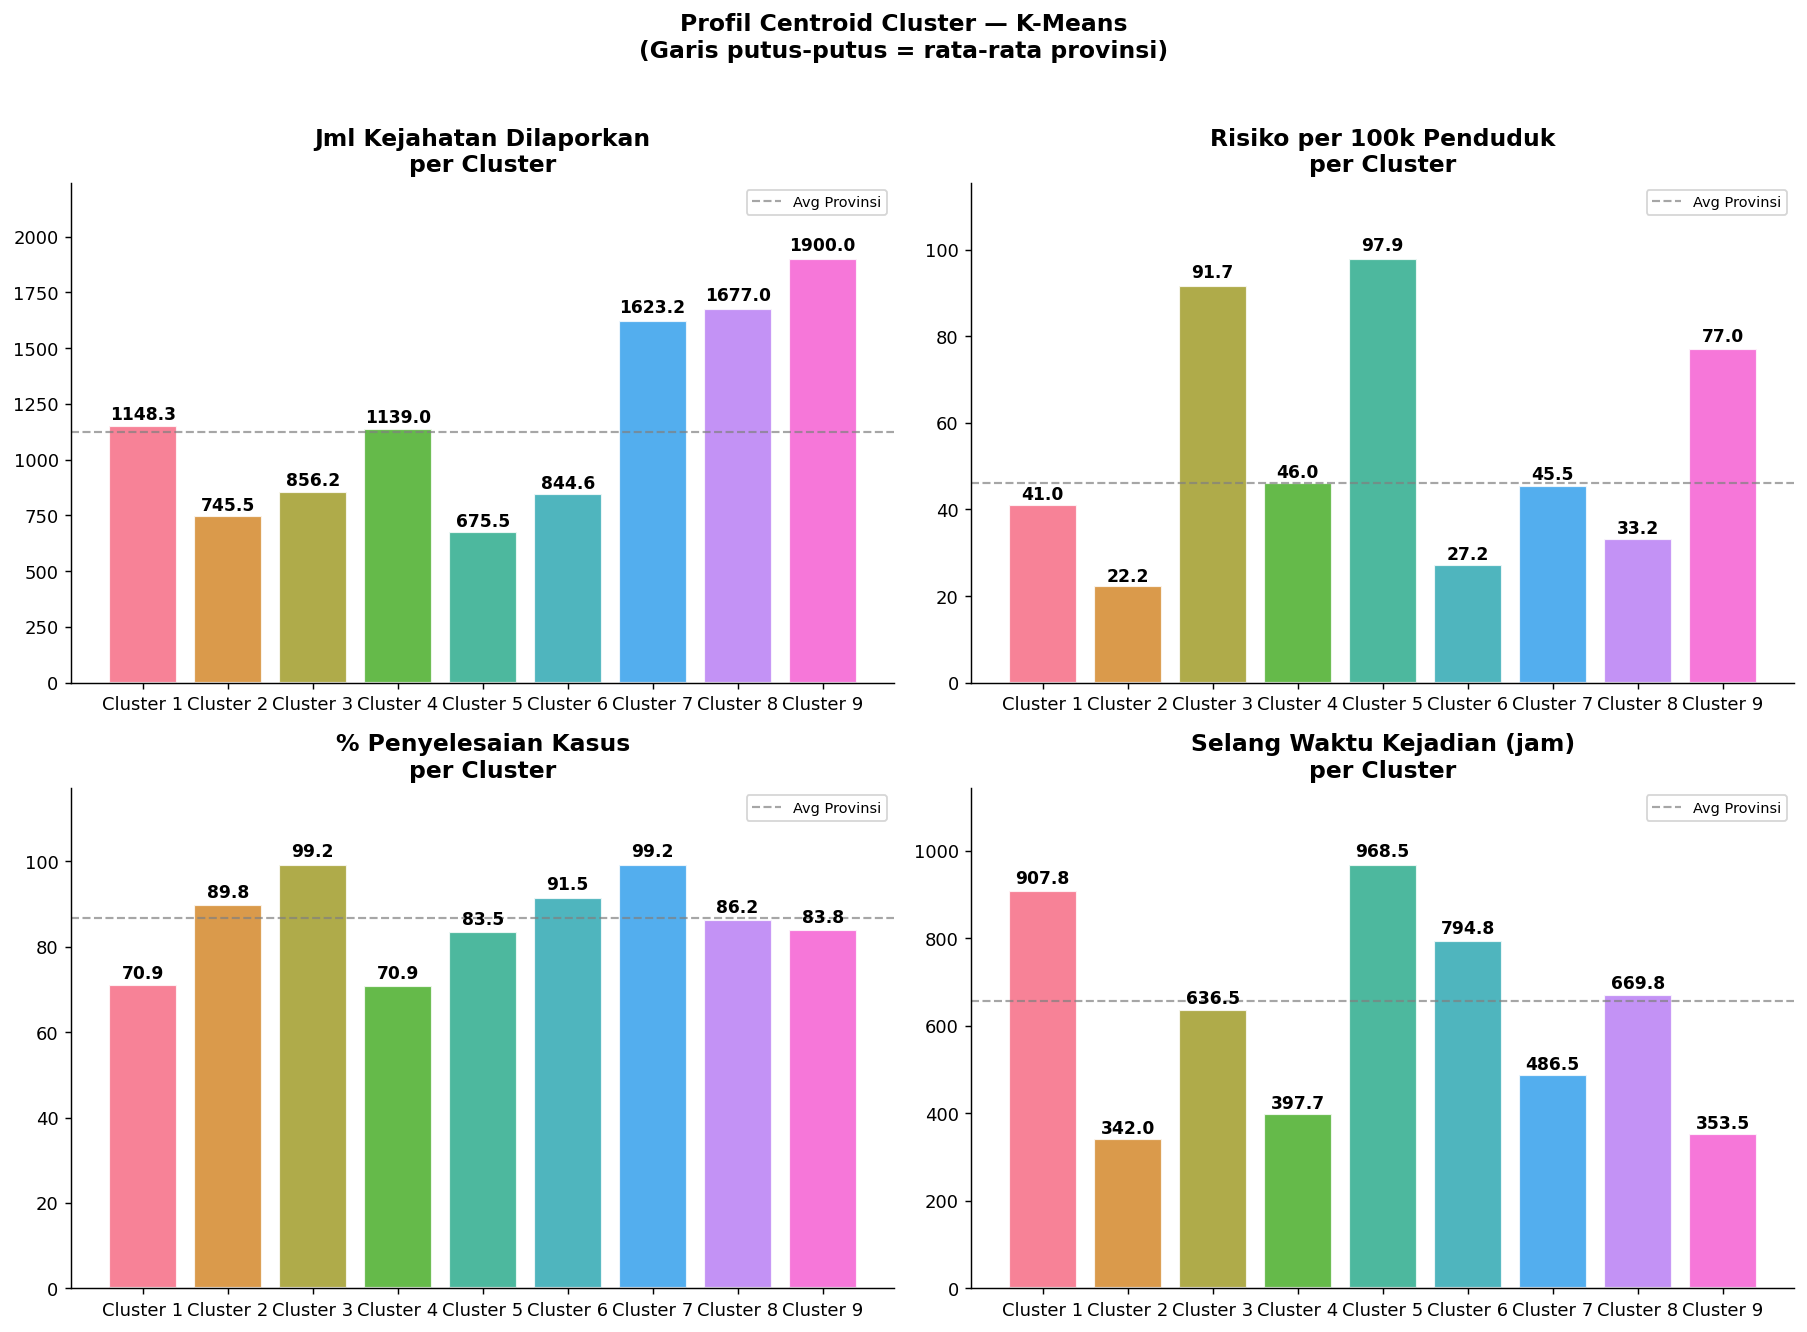

In [20]:
# ── Visualisasi Bar Chart Profil Cluster ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
col_list_bar = sns.color_palette('husl', OPTIMAL_K)
bar_labels   = list(FEATURE_LABELS.values())

for fi, (col, lbl) in enumerate(zip(FEATURE_COLS, bar_labels)):
    vals  = df_clean.groupby('Cluster_KMeans')[col].mean()
    idx   = [f'Cluster {i+1}' for i in vals.index]
    bars  = axes[fi].bar(idx, vals.values,
                          color=[col_list_bar[j] for j in range(OPTIMAL_K)],
                          edgecolor='white', linewidth=1.2, alpha=0.88)
    # Annotate values
    for bar, val in zip(bars, vals.values):
        axes[fi].text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() * 1.01, f'{val:.1f}',
                      ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    # Grand mean reference line
    axes[fi].axhline(df_clean[col].mean(), color='grey', linestyle='--',
                     linewidth=1.2, alpha=0.7, label='Avg Provinsi')
    axes[fi].set_title(f'{lbl.replace(chr(10), " ")}\nper Cluster', fontweight='bold')
    axes[fi].legend(fontsize=8)
    axes[fi].set_ylim(0, vals.max() * 1.18)

fig.suptitle('Profil Centroid Cluster — K-Means\n'
             '(Garis putus-putus = rata-rata provinsi)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cluster_profiles.png', bbox_inches='tight', dpi=130)
plt.show()

### 8.2 Pelabelan Profil Risiko Intuitif
Setiap cluster diberi label deskriptif berdasarkan **Danger Score komposit** yang
mempertimbangkan seluruh dimensi:

| Dimensi | Arah Berbahaya | Bobot |
|---|---|---|
| Jumlah Kejahatan | Tinggi | 25 % |
| Risiko per 100k  | Tinggi | 25 % |
| % Penyelesaian   | Rendah | 25 % |
| Selang Waktu     | Pendek (rendah) | 25 % |

In [21]:
# ── Hitung Danger Score Komposit ─────────────────────────────────────────────
max_crime  = centroid_tbl['Jml Kejahatan'].max()
max_risk   = centroid_tbl['Risiko/100k'].max()
max_pct    = centroid_tbl['% Penyelesaian'].max()
max_selang = centroid_tbl['Selang Waktu'].max()

centroid_tbl['Danger_Score'] = (
    (centroid_tbl['Jml Kejahatan']   / max_crime)  * 25 +
    (centroid_tbl['Risiko/100k']     / max_risk)   * 25 +
    (1 - centroid_tbl['% Penyelesaian'] / max_pct) * 25 +
    (1 - centroid_tbl['Selang Waktu']  / max_selang) * 25
).round(2)

centroid_tbl_s = centroid_tbl.sort_values('Danger_Score', ascending=False).reset_index(drop=False)

# ── Assign Risk Labels berdasarkan rank Danger Score (dinamis untuk K apapun) ─
def get_risk_label(rank, total):
    pct = rank / max(total - 1, 1)
    if pct < 0.25:
        return '🔴 High Risk – Low Resolution'
    elif pct < 0.50:
        return '🟠 Moderate-High Risk – Needs Attention'
    elif pct < 0.75:
        return '🟡 Moderate-Low Risk – Watch Zone'
    else:
        return '🟢 Safe Zone – Low Priority'

n_clusters_actual = len(centroid_tbl_s)
centroid_tbl_s['Profil Risiko'] = [
    get_risk_label(i, n_clusters_actual) for i in range(n_clusters_actual)
]

print("=" * 85)
print("  TABEL PROFIL RISIKO CLUSTER — FINAL")
print("=" * 85)
display_cols = ['index', 'Jml Kejahatan', 'Risiko/100k',
                '% Penyelesaian', 'Selang Waktu', 'N Daerah',
                'Danger_Score', 'Profil Risiko']
print(centroid_tbl_s[display_cols].rename(columns={'index': 'Cluster'}).to_string(index=False))

  TABEL PROFIL RISIKO CLUSTER — FINAL
  Cluster  Jml Kejahatan  Risiko/100k  % Penyelesaian  Selang Waktu  N Daerah  Danger_Score                          Profil Risiko
Cluster 9        1900.00        77.00           83.85        353.50         2         64.42           🔴 High Risk – Low Resolution
Cluster 4        1139.00        46.00           70.86        397.67         3         48.62           🔴 High Risk – Low Resolution
Cluster 7        1623.25        45.50           99.23        486.50         4         45.42 🟠 Moderate-High Risk – Needs Attention
Cluster 3         856.25        91.66           99.20        636.52         4         43.25 🟠 Moderate-High Risk – Needs Attention
Cluster 8        1677.00        33.25           86.25        669.75         4         41.54       🟡 Moderate-Low Risk – Watch Zone
Cluster 5         675.50        97.88           83.52        968.50         2         37.85       🟡 Moderate-Low Risk – Watch Zone
Cluster 1        1148.33        41.00        

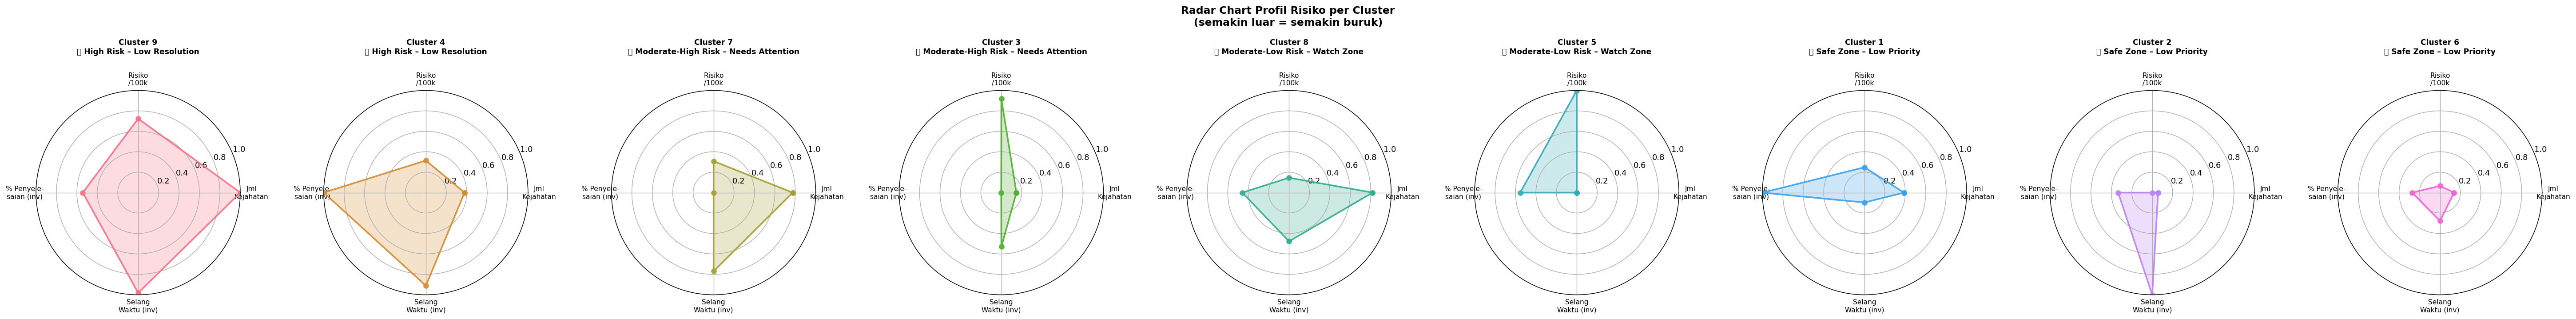

In [22]:
# ── Radar Chart / Spider Plot per Cluster ────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

# Normalisasi 0-1 untuk Radar
radar_data = centroid_tbl_s.set_index('index')[
    ['Jml Kejahatan', 'Risiko/100k', '% Penyelesaian', 'Selang Waktu']
].copy()

# Risiko dan kejahatan: min=baik, max=buruk → normalize as-is
# Penyelesaian dan Selang Waktu: max=baik → invert
radar_norm = radar_data.copy()
for col in radar_norm.columns:
    col_min, col_max = radar_norm[col].min(), radar_norm[col].max()
    radar_norm[col] = (radar_norm[col] - col_min) / (col_max - col_min + 1e-9)

# Invert "baik jika tinggi" metrics agar arah "luar" = lebih buruk
for good_col in ['% Penyelesaian', 'Selang Waktu']:
    radar_norm[good_col] = 1 - radar_norm[good_col]

categories  = ['Jml\nKejahatan', 'Risiko\n/100k', '% Penyele-\nsaian (inv)',
               'Selang\nWaktu (inv)']
N           = len(categories)
angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles     += angles[:1]

fig, axes_r = plt.subplots(1, n_clusters_actual,
                            figsize=(5 * n_clusters_actual, 5),
                            subplot_kw=dict(polar=True))
if n_clusters_actual == 1:
    axes_r = [axes_r]

for i, (cl_name, ax_r) in enumerate(zip(radar_norm.index, axes_r)):
    vals = radar_norm.loc[cl_name].tolist()
    vals += vals[:1]
    ax_r.plot(angles, vals, 'o-', linewidth=2, color=col_list[i], alpha=0.9)
    ax_r.fill(angles, vals, alpha=0.25, color=col_list[i])
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(categories, fontsize=8.5)
    ax_r.set_ylim(0, 1)
    risk_lbl = centroid_tbl_s.loc[
        centroid_tbl_s['index'] == cl_name, 'Profil Risiko'
    ].values[0]
    ax_r.set_title(f'{cl_name}\n{risk_lbl}', fontsize=9.5,
                   fontweight='bold', pad=15, y=1.12)

fig.suptitle('Radar Chart Profil Risiko per Cluster\n'
             '(semakin luar = semakin buruk)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight', dpi=130)
plt.show()

In [23]:
# ── Peta Daerah per Cluster + Risk Label ─────────────────────────────────────
# Gabungkan cluster label kembali ke df_clean untuk referensi
cluster_label_map = centroid_tbl_s.set_index('index')['Profil Risiko'].to_dict()
df_clean['Risk_Label'] = df_clean['Cluster_KMeans'].map(
    lambda x: cluster_label_map.get(f'Cluster {x+1}', 'Unknown')
)

# Print daftar daerah per profil risiko
print("\n📋  DAFTAR DAERAH BERDASARKAN PROFIL RISIKO")
print("=" * 70)
for cl_name, risk in cluster_label_map.items():
    cl_id  = int(cl_name.replace('Cluster ', '')) - 1
    members = df_clean.loc[df_clean['Cluster_KMeans'] == cl_id, 'Kabupaten_Kota'].tolist()
    print(f"\n  {risk}")
    print(f"  ({len(members)} Daerah): {', '.join(sorted(members))}")


📋  DAFTAR DAERAH BERDASARKAN PROFIL RISIKO

  🔴 High Risk – Low Resolution
  (2 Daerah): Gresik, Malang

  🔴 High Risk – Low Resolution
  (3 Daerah): Banyuwangi, Lumajang, Situbondo

  🟠 Moderate-High Risk – Needs Attention
  (4 Daerah): Jember, Kota Surabaya, Sidoarjo, Tulungagung

  🟠 Moderate-High Risk – Needs Attention
  (4 Daerah): Kota Mojokerto, Kota Probolinggo, Magetan, Ngawi

  🟡 Moderate-Low Risk – Watch Zone
  (4 Daerah): Jombang, Kediri, Lamongan, Pasuruan

  🟡 Moderate-Low Risk – Watch Zone
  (2 Daerah): Kota Kediri, Kota Pasuruan

  🟢 Safe Zone – Low Priority
  (6 Daerah): Bondowoso, Kota Malang, Mojokerto, Pamekasan, Sumenep, Tuban

  🟢 Safe Zone – Low Priority
  (4 Daerah): Blitar, Bojonegoro, Kota Blitar, Pacitan

  🟢 Safe Zone – Low Priority
  (9 Daerah): Bangkalan, Kota Batu, Kota Madiun, Madiun, Nganjuk, Ponorogo, Probolinggo, Sampang, Trenggalek


In [24]:
# ── Plotly: Interactive Profil Cluster ───────────────────────────────────────
fig_radar = go.Figure()

for i, cl_name in enumerate(radar_norm.index):
    vals    = radar_norm.loc[cl_name].tolist()
    risk_lbl = centroid_tbl_s.loc[
        centroid_tbl_s['index'] == cl_name, 'Profil Risiko'
    ].values[0]
    fig_radar.add_trace(go.Scatterpolar(
        r      = vals + [vals[0]],
        theta  = ['Jml Kejahatan', 'Risiko/100k',
                  '% Penyelesaian (inv)', 'Selang Waktu (inv)',
                  'Jml Kejahatan'],
        fill   = 'toself',
        opacity = 0.65,
        name   = f'{cl_name} — {risk_lbl}',
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=dict(
        text='<b>Radar Chart Profil Risiko Cluster (Interactive)</b><br>'
             '<sup>Nilai ternormalisasi; arah luar = kondisi lebih buruk</sup>',
        font=dict(size=14)
    ),
    template='plotly_white',
    width=750, height=550,
)
fig_radar.show()

## 9. Rekomendasi Strategis Pemerintah Daerah <a id='9-rekomendasi'></a>

---

### 🔴 Cluster "High Risk – Low Resolution"
**Karakteristik:** Jumlah kejahatan tinggi, risiko per kapita besar, tingkat penyelesaian kasus rendah, dan frekuensi kejadian tinggi.

**Rekomendasi:**
- **Penambahan personil Polri** secara segera — prioritas utama redistribusi aset keamanan provinsi
- **Program percepatan penyelesaian kasus** (`case clearance rate`): pelatihan penyidik, pemanfaatan teknologi forensik digital
- **Pos Keamanan Terpadu (Poskamtibmas)** di titik-titik kriminalitas tinggi berbasis pemetaan GIS
- **Perkuat unit intelijen kriminal** untuk investigasi proaktif, bukan reaktif

---

### 🟠 Cluster "Moderate-High Risk – Needs Attention"
**Karakteristik:** Frekuensi kejahatan dan risiko di atas rata-rata, penyelesaian kasus masih dapat diperbaiki.

**Rekomendasi:**
- **Patroli preventif intensif** pada jam dan lokasi rawan (analisis *hotspot*)
- **Peningkatan koordinasi** antara Polri–Satpol PP–Pemerintah Daerah untuk respons lintas-sektoral
- **Investasi CCTV & sistem pelaporan digital** untuk mempercepat waktu respons
- **Program pemberdayaan ekonomi komunitas** untuk menyasar akar kejahatan berbasis kemiskinan
- Monitoring ketat agar tidak bergeser ke kategori *High Risk*

---

### 🟡 Cluster "Moderate-Low Risk – Watch Zone"
**Karakteristik:** Profil keamanan relatif stabil, namun perlu dijaga agar tidak meningkat.

**Rekomendasi:**
- **Pertahankan kapasitas penegakan hukum** yang sudah berjalan efektif
- **Program komunitas (Siskamling 4.0):** digitalisasi sistem keamanan berbasis RT/RW
- **Evaluasi periodik** terhadap tren kriminalitas — deteksi dini pola anomali musiman
- Alokasi anggaran keamanan **proporsional** — tidak perlu ekspansi besar, fokus pada pemeliharaan

---

### 🟢 Cluster "Safe Zone – Low Priority"
**Karakteristik:** Kriminalitas rendah, risiko per kapita kecil, tingkat penyelesaian baik, frekuensi kejadian panjang.

**Rekomendasi:**
- **Jadikan sebagai model percontohan** bagi daerah dengan profil lebih tinggi
- **Redistribusi sumber daya** (personil, anggaran) dari zona ini ke zona *High Risk*
- **Perkuat sistem pencegahan berbasis masyarakat** untuk mempertahankan kondisi aman
- **Investasi pada kualitas SDM aparat** (pendidikan lanjutan, pelatihan spesialisasi)

---

### 📌 Rekomendasi Lintas-Cluster (Provinsi)

| Prioritas | Aksi | Target Cluster |
|:---:|---|---|
| 🥇 | Redistribusi personil Polri dari Safe Zone ke High Risk | Semua |
| 🥈 | Platform data kriminalitas terintegrasi (Big Data Polda Jatim) | Semua |
| 🥉 | Sistem early-warning berbasis ML untuk prediksi lonjakan kriminalitas | High & Moderate |
| 4 | Anggaran keamanan berbasis *risk score* bukan rata rata merata | Semua |
| 5 | Review tahunan segmentasi cluster menggunakan data terbaru | Semua |

---
> **Catatan Metodologi:** Analisis ini didasarkan pada median multi-tahun (2020–2024) untuk meminimalkan bias anomali tahun tertentu. Segmentasi bersifat dinamis dan perlu diperbarui setiap tahun dengan data terkini. Keputusan kebijakan harus dikombinasikan dengan konteks lapangan dan keahlian domain dari aparat keamanan setempat.

### 9.1 Catatan Implementasi untuk Cluster Kecil

- Dalam analisis ini, konfigurasi operasional diprioritaskan pada K yang memenuhi syarat minimum anggota cluster >=4.
- Jika konfigurasi granular seperti K=9 tetap digunakan untuk eksplorasi, maka cluster dengan 1-2 anggota harus diperlakukan sebagai **kasus khusus**.
- Cluster kasus khusus wajib melalui verifikasi lapangan (data kriminal mikro, karakter sosial lokal, validasi aparat wilayah) sebelum dijadikan dasar kebijakan langsung.
- Rekomendasi alokasi sumber daya skala provinsi tidak boleh hanya bertumpu pada cluster beranggota sangat kecil tanpa penggabungan/konfirmasi tambahan.

---
## 📊 Ringkasan Statistik Analisis

| Metrik | Nilai |
|---|---|
| Jumlah Kabupaten/Kota | 38 |
| Periode Data | 2020 – 2024 (Median) |
| Jumlah Fitur | 4 |
| Jumlah Cluster Optimal | `OPTIMAL_K` |
| K-Means Silhouette Score | *lihat output Cell 5* |
| HC Ward Silhouette Score | *lihat output Cell 6* |
| PCA Variance Explained (2D) | *lihat output Cell 7* |
| Adjusted Rand Index | *lihat output Cell 6* |

*Notebook dibuat oleh: Senior Data Science Team | Sumber data: Kepolisian Daerah Jawa Timur*